In [1]:
!pip install --quiet \
    datasets \
    kaggle \
    huggingface_hub \
    lightgbm \
    mlflow \
    pandas \
    scikit-learn \
    joblib \
    networkx \
    loguru \
    xgboost \
    catboost \
    optuna \
    shap \
    pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 69.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 76.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.7 MB/s eta 0:00:00


In [3]:
# download_and_save.py
import os
from pathlib import Path
import json
import sys
import pandas as pd
from loguru import logger

OUT = Path(os.getenv("OUTPUT_DIR", "/kaggle/working/artifacts"))
RAW = OUT / "raw"
RAW.mkdir(parents=True, exist_ok=True)

# 1) PaySim via kagglehub (preferred) or fallback search
def download_paysim():
    try:
        import kagglehub
        logger.info("Using kagglehub to download PaySim")
        path = kagglehub.dataset_download("ealaxi/paysim1")  # returns local path or dir
        logger.info(f"PAYSIM dataset downloaded to {path}")
        # find CSV(s) under path
        for p in Path(path).rglob("*.csv"):
            df = pd.read_csv(p, low_memory=False)
            df.to_parquet(RAW / "paysim.parquet", index=False)
            logger.info(f"Saved PaySim as parquet ({p.name})")
            break
    except Exception as e:
        logger.warning(f"kagglehub not available or failed: {e}. Trying Kaggle CLI / local input search.")
        # fallback: try Kaggle CLI dataset path or /kaggle/input
        cand = None
        for p in Path("/kaggle/input").rglob("*.csv"):
            if "paysim" in p.name.lower() or "paysim" in str(p).lower():
                cand = p
                break
        if cand:
            df = pd.read_csv(cand, low_memory=False)
            df.to_parquet(RAW / "paysim.parquet", index=False)
            logger.info(f"Saved PaySim from {cand}")
        else:
            logger.error("PaySim not found in /kaggle/input; set PAYSIM_PATH env var.")

# 2) CIFER via Hugging Face datasets
def download_cifer():
    try:
        from datasets import load_dataset
        logger.info("Loading CIFER via datasets.load_dataset('Durgesh111/Cifer-Fraud-Detection-Dataset-AF')")
        ds = load_dataset("Durgesh111/Cifer-Fraud-Detection-Dataset-AF", split="train")
        # save a sample + metadata schema
        df = ds.to_pandas()
        # keep a sampled subset (full 21M can be huge); save sample and schema
        sample = df.sample(n=min(len(df), 200000), random_state=42)
        sample.to_parquet(RAW / "cifer_sample.parquet", index=False)
        with open(RAW / "cifer_schema.json","w") as f:
            json.dump({k: str(v) for k,v in ds.features.items()}, f, indent=2)
        logger.info("Saved CIFER sample + schema")
    except Exception as e:
        logger.exception("Failed to load CIFER dataset: " + str(e))

# 3) Nigerian dataset via Hugging Face datasets
def download_nigerian():
    try:
        from datasets import load_dataset
        logger.info("Loading Nigerian dataset via datasets.load_dataset('electricsheepafrica/Nigerian-Financial-Transactions-and-Fraud-Detection-Dataset')")
        ds = load_dataset("electricsheepafrica/Nigerian-Financial-Transactions-and-Fraud-Detection-Dataset", split="train")
        df = ds.to_pandas()
        # save full if small enough, otherwise sample & schema
        if len(df) <= 2_000_000:
            df.to_parquet(RAW / "nigerian.parquet", index=False)
            logger.info("Saved full Nigerian dataset")
        else:
            df.sample(n=500000, random_state=42).to_parquet(RAW / "nigerian_sample.parquet", index=False)
            logger.info("Saved Nigerian sample (large dataset)")
        with open(RAW / "nigerian_schema.json","w") as f:
            json.dump({k: str(v) for k,v in ds.features.items()}, f, indent=2)
        logger.info("Saved Nigerian schema")
    except Exception as e:
        logger.exception("Failed to load Nigerian dataset: " + str(e))

if __name__ == "__main__":
    download_paysim()
    download_cifer()
    download_nigerian()
    logger.info(f"Raw artifacts saved to {RAW}")

2026-02-20 03:19:35.672 | INFO     | __main__:download_paysim:17 - Using kagglehub to download PaySim
2026-02-20 03:19:35.775 | INFO     | __main__:download_paysim:19 - PAYSIM dataset downloaded to /kaggle/input/datasets/ealaxi/paysim1
2026-02-20 03:19:54.713 | INFO     | __main__:download_paysim:24 - Saved PaySim as parquet (PS_20174392719_1491204439457_log.csv)
2026-02-20 03:19:54.989 | INFO     | __main__:download_cifer:45 - Loading CIFER via datasets.load_dataset('Durgesh111/Cifer-Fraud-Detection-Dataset-AF')
2026-02-20 03:20:13.980 | INFO     | __main__:download_cifer:54 - Saved CIFER sample + schema
2026-02-20 03:20:15.617 | INFO     | __main__:download_nigerian:62 - Loading Nigerian dataset via datasets.load_dataset('electricsheepafrica/Nigerian-Financial-Transactions-and-Fraud-Detection-Dataset')
2026-02-20 03:20:27.757 | INFO     | __main__:download_nigerian:71 - Saved Nigerian sample (large dataset)
2026-02-20 03:20:27.760 | INFO     | __main__:download_nigerian:74 - Saved Ni

In [35]:
# guardianx_nsi_prod.py
# Production-ready Network Security Intelligence training script
# Uses: PaySim, CIFER, Nigerian datasets -> network-only features -> LightGBM model

import os
from pathlib import Path
import numpy as np
import pandas as pd
from loguru import logger
import joblib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# Config
# -------------------------
ARTIFACT_DIR = Path(os.getenv("ARTIFACT_DIR", "/kaggle/working/artifacts"))
RAW_DIR = ARTIFACT_DIR / "raw"
MODEL_DIR = ARTIFACT_DIR / "models"
FEATURE_DIR = ARTIFACT_DIR / "features"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = int(os.getenv("RANDOM_STATE", 42))
SAMPLE_LIMIT = int(os.getenv("SAMPLE_LIMIT", 2_000_000))  # set to 0 for no limit

logger.remove()
logger.add(lambda msg: print(msg, end=""))

# -------------------------
# Dataset loading + adapters
# -------------------------
def load_parquet_if_exists(path: Path):
    if path.exists():
        logger.info(f"Loading parquet: {path}")
        return pd.read_parquet(path)
    return None

def load_datasets():
    """Load PaySim, Cifer, Nigerian datasets from RAW_DIR if present, else try HF (best-effort)."""
    frames = []

    # PaySim
    paysim = load_parquet_if_exists(RAW_DIR / "paysim.parquet")
    if paysim is None:
        # try common CSV
        cand = next(RAW_DIR.rglob("*paysim*.csv"), None)
        if cand:
            paysim = pd.read_csv(cand, low_memory=False)
    if paysim is not None:
        frames.append(("paysim", paysim))

    # CIFER
    cifer = load_parquet_if_exists(RAW_DIR / "cifer_sample.parquet")
    if cifer is not None:
        frames.append(("cifer", cifer))

    # Nigerian
    niger = load_parquet_if_exists(RAW_DIR / "nigerian.parquet") or load_parquet_if_exists(RAW_DIR / "nigerian_sample.parquet")
    if niger is not None:
        frames.append(("nigerian", niger))

    # If nothing found, try Hugging Face (best-effort)
    if not frames:
        try:
            from datasets import load_dataset
            logger.info("No local raw datasets; attempting to download small samples from Hugging Face (requires internet).")
            try:
                ds = load_dataset("ealaxi/paysim", split="train")
                df = ds.to_pandas()
                frames.append(("paysim", df))
            except Exception:
                pass
            try:
                ds = load_dataset("Durgesh111/Cifer-Fraud-Detection-Dataset-AF", split="train")
                df = ds.to_pandas().sample(n=min(len(ds), 200_000), random_state=RANDOM_STATE)
                frames.append(("cifer", df))
            except Exception:
                pass
            try:
                ds = load_dataset("electricsheepafrica/Nigerian-Financial-Transactions-and-Fraud-Detection-Dataset", split="train")
                df = ds.to_pandas().sample(n=min(len(ds), 200_000), random_state=RANDOM_STATE)
                frames.append(("nigerian", df))
            except Exception:
                pass
        except Exception as e:
            logger.warning("datasets library not available or failed: " + str(e))

    if not frames:
        raise FileNotFoundError(f"No datasets found under {RAW_DIR} and HF fetch failed. Place paysim.parquet, cifer_sample.parquet, or nigerian.parquet in {RAW_DIR}.")

    return frames

# -------------------------
# Convert fraud datasets -> network logs (deterministic)
# -------------------------
def paysim_to_network(df: pd.DataFrame):
    """Map PaySim to network-like logs."""
    df = df.copy()
    # ensure columns
    if "step" not in df.columns:
        df["step"] = np.arange(len(df))
    if "amount" not in df.columns:
        df["amount"] = 0.0
    # source account
    if "nameOrig" in df.columns:
        df["user_id"] = df["nameOrig"].astype(str)
    else:
        df["user_id"] = "u_" + df.index.astype(str)
    # dest account
    if "nameDest" in df.columns:
        df["dest_id"] = df["nameDest"].astype(str)
    else:
        df["dest_id"] = "d_" + df.index.astype(str)
    # label
    if "isFraud" in df.columns:
        df["label"] = df["isFraud"].astype(int)
    else:
        df["label"] = 0
    # deterministic synthetic IP and device
    df["ip_address"] = (df["step"].astype(int) % 255).astype(str) + "." + (df["amount"].fillna(0).astype(int) % 255).astype(str) + ".1.1"
    df["device_id"] = ("dev_" + df["user_id"].astype(str).str[:8]).astype(str)
    df["timestamp"] = pd.to_datetime(df["step"], unit="s", origin="unix", errors="coerce").fillna(pd.Timestamp("1970-01-01"))
    return df[["ip_address", "device_id", "user_id", "dest_id", "timestamp", "label", "step"]]

def nigerian_to_network(df: pd.DataFrame):
    df = df.copy()
    # label heuristics
    if "is_fraud" in df.columns:
        df["label"] = df["is_fraud"].astype(int)
    elif "fraud_flag" in df.columns:
        df["label"] = df["fraud_flag"].astype(int)
    else:
        df["label"] = 0
    # user
    if "nameOrig" in df.columns:
        df["user_id"] = df["nameOrig"].astype(str)
    else:
        df["user_id"] = "u_" + df.index.astype(str)
    # dest
    if "nameDest" in df.columns:
        df["dest_id"] = df["nameDest"].astype(str)
    else:
        df["dest_id"] = "d_" + df.index.astype(str)
    df["step"] = df.index.astype(int)
    df["ip_address"] = (df.index % 255).astype(str) + ".10.10.10"
    df["device_id"] = ("dev_" + df["user_id"].astype(str).str[:8]).astype(str)
    df["timestamp"] = pd.to_datetime(df["step"], unit="s", origin="unix", errors="coerce").fillna(pd.Timestamp("1970-01-01"))
    return df[["ip_address", "device_id", "user_id", "dest_id", "timestamp", "label", "step"]]

def cifer_to_network(df: pd.DataFrame):
    df = df.copy()
    # try common label columns
    if "label" in df.columns:
        df["label"] = df["label"].astype(int)
    else:
        df["label"] = 0
    df["user_id"] = df.index.astype(str)
    df["dest_id"] = "d_" + df.index.astype(str)
    df["step"] = df.index.astype(int)
    df["ip_address"] = (df.index % 255).astype(str) + ".20.20.20"
    df["device_id"] = "dev_" + (df.index % 50000).astype(str)
    df["timestamp"] = pd.to_datetime(df["step"], unit="s", origin="unix", errors="coerce").fillna(pd.Timestamp("1970-01-01"))
    return df[["ip_address", "device_id", "user_id", "dest_id", "timestamp", "label", "step"]]

# -------------------------
# Network feature builder (pure network signals)
# -------------------------
def build_network_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input columns expected (at least): ip_address, device_id, user_id, dest_id, step (or timestamp).
    Returns numeric-only features (no raw identifiers).
    """
    df = df.copy()
    n = len(df)
    if n == 0:
        return pd.DataFrame()

    # normalize columns
    for col in ["ip_address", "device_id", "user_id", "dest_id"]:
        if col not in df.columns:
            df[col] = "na"

    if "step" not in df.columns:
        df["step"] = np.arange(n)

    # ensure timestamp as datetime if present
    if "timestamp" in df.columns:
        try:
            df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        except Exception:
            df["timestamp"] = pd.NaT
    else:
        df["timestamp"] = pd.NaT

    # IP counts
    ip_counts = df["ip_address"].value_counts()
    df["ip_freq"] = df["ip_address"].map(ip_counts).fillna(0).astype("int32")

    # Subnet 24
    df["subnet_24"] = df["ip_address"].astype(str).str.split(".").str[:3].str.join(".")
    subnet_counts = df["subnet_24"].value_counts()
    df["subnet_freq"] = df["subnet_24"].map(subnet_counts).fillna(0).astype("int32")

    # accounts (users) per IP: fan-in
    df["accounts_per_ip"] = df.groupby("ip_address")["user_id"].transform("nunique").astype("int16")

    # unique destinations per IP (fan-out)
    df["dest_per_ip"] = df.groupby("ip_address")["dest_id"].transform("nunique").astype("int16")

    # device frequency
    dev_counts = df["device_id"].value_counts()
    df["device_freq"] = df["device_id"].map(dev_counts).fillna(0).astype("int32")

    # device reuse per IP (devices per ip)
    df["devices_per_ip"] = df.groupby("ip_address")["device_id"].transform("nunique").astype("int16")

    # rapid-fire / gap: use 'step' as integer timestamp proxy
    df = df.sort_values("step")
    df["ip_tx_gap"] = df.groupby("ip_address")["step"].diff().fillna(1e9).astype("float32")
    df["rapid_fire_ip"] = (df["ip_tx_gap"] <= 2).astype("int8")

    # rolling burst count per IP (window=5)
    df["ip_burst_5"] = (
        df.groupby("ip_address")["rapid_fire_ip"]
        .rolling(5, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
        .astype("float32")
    )

    # time-based velocity: tx per ip per window approximated via counts within +/-k steps (cheap proxy)
    # Here we create local windows by counting within same 'hour' bucket if step is in seconds
    df["hour_bucket"] = (df["step"] // 3600).astype("int64")
    df["tx_ip_hour"] = df.groupby(["ip_address", "hour_bucket"])["step"].transform("count").astype("int32")

    # proxy signals (heuristic): many user_ids behind one ip
    df["high_fan_in_ip"] = (df["accounts_per_ip"] > 5).astype("int8")
    df["high_subnet_activity"] = (df["subnet_freq"] > 50).astype("int8")
    df["device_anomaly"] = (df["device_freq"] <= 1).astype("int8")  # one-off devices (possible bots or new devices)

    # simple entropy-like proxy: number of unique devices/user per ip
    df["device_user_ratio"] = np.where(df["devices_per_ip"] == 0, 0.0, df["accounts_per_ip"] / (df["devices_per_ip"] + 1e-6)).astype("float32")

    # final numeric selection (drop raw ids)
    numeric_cols = [
        "ip_freq", "subnet_freq", "accounts_per_ip", "dest_per_ip",
        "device_freq", "devices_per_ip", "ip_tx_gap", "rapid_fire_ip",
        "ip_burst_5", "tx_ip_hour", "high_fan_in_ip", "high_subnet_activity",
        "device_anomaly", "device_user_ratio"
    ]
    feat = df[numeric_cols].copy()
    feat = feat.replace([np.inf, -np.inf], 0).fillna(0)
    # ensure numeric dtypes
    for c in feat.columns:
        feat[c] = pd.to_numeric(feat[c], errors="coerce").fillna(0)

    return feat

# -------------------------
# Main training + pipeline
# -------------------------
class NetworkThreatDetectionModel:
    def __init__(self):
        self.model = None
        self.calibrator = None
        self.feature_columns = None

    def train(self, X: pd.DataFrame, y: pd.Series):
        logger.info("Building network features from raw X")
        X_feat = build_network_features(X)
        if X_feat.shape[0] == 0:
            raise ValueError("No training rows after feature building")

        # align with labels
        y = y.reindex(X_feat.index).fillna(0).astype(int)

        # optional downsample to SAMPLE_LIMIT
        if SAMPLE_LIMIT and len(X_feat) > SAMPLE_LIMIT:
            logger.info(f"Downsampling training set to {SAMPLE_LIMIT} rows for memory safety")
            sampled_idx = X_feat.sample(n=SAMPLE_LIMIT, random_state=RANDOM_STATE).index
            X_feat = X_feat.loc[sampled_idx]
            y = y.loc[sampled_idx]

        self.feature_columns = X_feat.columns.tolist()

        # train/val split - try stratify, else fallback
        stratify = y if y.nunique() > 1 and y.sum() > 2 else None
        X_train, X_val, y_train, y_val = train_test_split(
            X_feat, y, test_size=0.2, stratify=stratify, random_state=RANDOM_STATE
        )

        # handle class imbalance
        pos = int(y_train.sum())
        neg = len(y_train) - pos
        scale_pos_weight = float(neg / max(pos, 1))
        logger.info(f"scale_pos_weight={scale_pos_weight:.2f} (pos={pos}, neg={neg})")

        # LightGBM config (production-oriented)
        model = lgb.LGBMClassifier(
            n_estimators=600,
            learning_rate=0.035,
            num_leaves=128,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_samples=80,
            reg_alpha=0.6,
            reg_lambda=0.6,
            force_col_wise=True,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            scale_pos_weight=scale_pos_weight,
        )

        logger.info("Fitting LightGBM (this may take a while)...")
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lgb.log_evaluation(period=0)]
        )

        # Calibration - cross-validated to avoid deprecation and be future-proof
        logger.info("Calibrating probabilities (CalibratedClassifierCV, cv=3)...")
        self.calibrator = CalibratedClassifierCV(estimator=model, method="isotonic", cv=3, n_jobs=-1)
        # fit calibrator on validation set (it internally refits estimator across folds)
        self.calibrator.fit(X_val, y_val)

        # Evaluation
        try:
            val_probs = self.calibrator.predict_proba(X_val)[:, 1]
            roc = roc_auc_score(y_val, val_probs) if y_val.nunique() > 1 else float("nan")
            pr = average_precision_score(y_val, val_probs) if y_val.nunique() > 1 else float("nan")
            logger.info(f"VAL ROC-AUC: {roc:.4f}  PR-AUC: {pr:.4f}")
        except Exception as e:
            logger.warning("Could not compute metrics: " + str(e))

        self.model = model
        logger.info("Training finished.")

    def predict_proba(self, raw_df: pd.DataFrame):
        feats = build_network_features(raw_df)
        # align columns
        feats = feats.reindex(columns=self.feature_columns, fill_value=0)
        probs = self.calibrator.predict_proba(feats)[:, 1]
        return probs

    def save(self, path: Path):
        joblib.dump({
            "model": self.model,
            "calibrator": self.calibrator,
            "features": self.feature_columns
        }, path)
        logger.info(f"Saved model artifact to {path}")

    @staticmethod
    def load(path: Path):
        obj = joblib.load(path)
        m = NetworkThreatDetectionModel()
        m.model = obj["model"]
        m.calibrator = obj["calibrator"]
        m.feature_columns = obj["features"]
        return m

# -------------------------
# Orchestration: build combined frame from datasets
# -------------------------
def build_training_frame():
    frames = load_datasets()
    converted = []
    for name, df in frames:
        logger.info(f"Adapting dataset: {name} -> network log")
        if name.startswith("paysim"):
            net = paysim_to_network(df)
        elif name.startswith("niger"):
            net = nigerian_to_network(df)
        elif name.startswith("cifer"):
            net = cifer_to_network(df)
        else:
            # fallback generic mapping
            net = cifer_to_network(df)
        converted.append(net)

    # concat and drop duplicates index collisions
    combined = pd.concat(converted, ignore_index=True)
    logger.info(f"Combined training rows: {len(combined)}")

    # optional sample large combined frame to limit memory; default SAMPLE_LIMIT applied in train()
    # but we still persist features snapshot
    feat_snapshot = FEATURE_DIR / "training_raw_network.parquet"
    combined.to_parquet(feat_snapshot, index=False)
    logger.info(f"Saved raw network snapshot to {feat_snapshot}")
    return combined

# -------------------------
# CLI-style entrypoints (notebook safe)
# -------------------------
def train_nsi_from_datasets():
    logger.info("Starting NSI training from datasets...")
    df = build_training_frame()

    if "label" not in df.columns:
        df["label"] = 0
    features = df.drop(columns=["label"])
    labels = df["label"].astype(int)

    model = NetworkThreatDetectionModel()
    model.train(features, labels)

    model_path = MODEL_DIR / "network_threat_model.joblib"
    model.save(model_path)
    return model_path

def demo_run(model_path: Path = None):
    if model_path is None:
        model_path = MODEL_DIR / "network_threat_model.joblib"
    logger.info("Running demo...")
    model = NetworkThreatDetectionModel.load(model_path)
    sample_path = FEATURE_DIR / "training_raw_network.parquet"
    if not sample_path.exists():
        logger.error("No feature snapshot found; run training first.")
        return
    df = pd.read_parquet(sample_path).head(20)
    X = df.drop(columns=["label"])
    probs = model.predict_proba(X)
    print("Demo probs:", probs[:10])

# -------------------------
# Notebook-safe main
# -------------------------
# =============================
# MAIN (KAGGLE + CLI SAFE)
# =============================
def main():
    import argparse
    import sys

    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--cmd", default="train")

    # ✅ critical: ignore jupyter garbage args
    args, _ = parser.parse_known_args()

    cmd = args.cmd.lower()

    if cmd == "train":
        train_nsi_from_datasets()
    elif cmd == "demo":
        demo_run()
    else:
        logger.warning(f"Unknown cmd={cmd}, defaulting to train")
        train_nsi_from_datasets()


if __name__ == "__main__":
    main()

2026-02-20 05:51:30.206 | INFO     | __main__:train_nsi_from_datasets:404 - Starting NSI training from datasets...
2026-02-20 05:51:30.206 | INFO     | __main__:load_parquet_if_exists:39 - Loading parquet: /kaggle/working/artifacts/raw/paysim.parquet
2026-02-20 05:51:35.890 | INFO     | __main__:load_parquet_if_exists:39 - Loading parquet: /kaggle/working/artifacts/raw/cifer_sample.parquet
2026-02-20 05:51:35.988 | INFO     | __main__:load_parquet_if_exists:39 - Loading parquet: /kaggle/working/artifacts/raw/nigerian_sample.parquet
2026-02-20 05:51:36.762 | INFO     | __main__:build_training_frame:377 - Adapting dataset: paysim -> network log
2026-02-20 05:51:45.644 | INFO     | __main__:build_training_frame:377 - Adapting dataset: cifer -> network log
2026-02-20 05:51:45.920 | INFO     | __main__:build_training_frame:377 - Adapting dataset: nigerian -> network log
2026-02-20 05:51:47.192 | INFO     | __main__:build_training_frame:391 - Combined training rows: 7062620
2026-02-20 05:51:

In [29]:
# ============================================================
# FINTECH-GRADE NETWORK SECURITY INTELLIGENCE (NSI)
# Kaggle + Production Hardened
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
from loguru import logger
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
import joblib

# =============================
# PATHS
# =============================
ARTIFACT_DIR = Path("/kaggle/working/artifacts")
MODEL_DIR = ARTIFACT_DIR / "models"
FEATURE_DIR = ARTIFACT_DIR / "features"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

logger.remove()
logger.add(lambda msg: print(msg, end=""))

# ============================================================
# NETWORK THREAT MODEL
# ============================================================

class NetworkThreatDetectionModel:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = None
        self.calibrator = None
        self.feature_columns = None

    # =========================================================
    # 🔥 ADVANCED NETWORK FEATURES (FINTECH-GRADE)
    # =========================================================
    def _build_network_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # -----------------------------
        # IP INTELLIGENCE
        # -----------------------------
        if "ip_address" in df.columns:
            vc_ip = df["ip_address"].value_counts()

            df["ip_freq"] = df["ip_address"].map(vc_ip).astype("int32")

            # accounts per ip
            if "user_id" in df.columns:
                df["accounts_per_ip"] = (
                    df.groupby("ip_address")["user_id"]
                    .transform("nunique")
                    .astype("int16")
                )
            else:
                df["accounts_per_ip"] = 1

            # subnet risk
            df["subnet_24"] = df["ip_address"].str.split(".").str[:3].str.join(".")
            vc_sub = df["subnet_24"].value_counts()
            df["subnet_freq"] = df["subnet_24"].map(vc_sub).astype("int32")

        else:
            df["ip_freq"] = 1
            df["accounts_per_ip"] = 1
            df["subnet_freq"] = 1

        # -----------------------------
        # DEVICE INTELLIGENCE
        # -----------------------------
        if "device_id" in df.columns:
            vc_dev = df["device_id"].value_counts()
            df["device_freq"] = df["device_id"].map(vc_dev).astype("int32")
        else:
            df["device_freq"] = 1

        # -----------------------------
        # VELOCITY / BURST FEATURES
        # -----------------------------
        if "step" in df.columns and "ip_address" in df.columns:
            df = df.sort_values("step")

            df["ip_tx_gap"] = (
                df.groupby("ip_address")["step"]
                .diff()
                .fillna(9999)
                .astype("float32")
            )

            df["rapid_fire_ip"] = (df["ip_tx_gap"] < 2).astype("int8")

            # rolling burst count (VERY POWERFUL)
            df["ip_burst_5"] = (
                df.groupby("ip_address")["rapid_fire_ip"]
                .rolling(5)
                .sum()
                .reset_index(level=0, drop=True)
                .fillna(0)
                .astype("float32")
            )
        else:
            df["ip_tx_gap"] = 9999
            df["rapid_fire_ip"] = 0
            df["ip_burst_5"] = 0

        # -----------------------------
        # BOT / AUTOMATION SIGNALS
        # -----------------------------
        df["high_ip_pressure"] = (df["ip_freq"] > 50).astype("int8")
        df["multi_account_ip"] = (df["accounts_per_ip"] > 3).astype("int8")
        df["device_anomaly"] = (df["device_freq"] < 3).astype("int8")

        # -----------------------------
        # KEEP NUMERIC ONLY
        # -----------------------------
        numeric_df = df.select_dtypes(include=[np.number]).copy()

        numeric_df = numeric_df.replace([np.inf, -np.inf], 0).fillna(0)

        return numeric_df

    # =========================================================
    # TRAIN
    # =========================================================
    def train(self, features: pd.DataFrame, labels: pd.Series):
        logger.info("Starting FINTECH NSI training...")

        features = self._build_network_features(features)
        self.feature_columns = features.columns.tolist()

        X_train, X_val, y_train, y_val = train_test_split(
            features,
            labels,
            test_size=0.2,
            stratify=labels,
            random_state=42,
        )

        # -----------------------------
        # SCALE
        # -----------------------------
        X_train_s = pd.DataFrame(
            self.scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index,
        )

        X_val_s = pd.DataFrame(
            self.scaler.transform(X_val),
            columns=X_val.columns,
            index=X_val.index,
        )

        # -----------------------------
        # IMBALANCE
        # -----------------------------
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = neg / max(pos, 1)

        logger.info(f"scale_pos_weight={scale_pos_weight:.2f}")

        # =====================================================
        # 🔥 LIGHTGBM (PRODUCTION SAFE)
        # =====================================================
        base_model = lgb.LGBMClassifier(
            n_estimators=600,
            learning_rate=0.035,
            num_leaves=128,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_samples=80,
            reg_alpha=0.6,
            reg_lambda=0.6,
            force_col_wise=True,
            n_jobs=-1,
            random_state=42,
            scale_pos_weight=scale_pos_weight,
        )

        base_model.fit(
            X_train_s,
            y_train,
            eval_set=[(X_val_s, y_val)],
            eval_metric="auc",
            callbacks=[lgb.log_evaluation(period=0)],
        )

        # -----------------------------
        # CALIBRATION (NO LEAKAGE)
        # -----------------------------
        logger.info("Calibrating probabilities...")

        self.calibrator = CalibratedClassifierCV(
            base_model,
            method="isotonic",
            cv="prefit",
        )
        self.calibrator.fit(X_val_s, y_val)

        self.model = base_model
        logger.info("FINTECH NSI training finished.")

    # =========================================================
    # PREDICT
    # =========================================================
    def predict_proba(self, features: pd.DataFrame):
        features = self._build_network_features(features)

        # align columns
        features = features.reindex(columns=self.feature_columns, fill_value=0)

        X_scaled = self.scaler.transform(features)

        probs = self.calibrator.predict_proba(X_scaled)[:, 1]
        return probs

    # =========================================================
    # SAVE / LOAD
    # =========================================================
    def save_model(self, path: Path):
        joblib.dump(self, path)
        logger.info(f"Model saved to {path}")

    @staticmethod
    def load_model(path: Path):
        return joblib.load(path)


# ============================================================
# TRAIN PIPELINE
# ============================================================

def train_nsi_from_datasets():
    logger.info("Starting NSI training from datasets...")

    features_path = FEATURE_DIR / "training_features.parquet"
    df = pd.read_parquet(features_path)

    label_col = "label"
    features = df.drop(columns=[label_col])
    labels = df[label_col]

    model = NetworkThreatDetectionModel()
    model.train(features, labels)

    model_path = MODEL_DIR / "network_threat_model.joblib"
    model.save_model(model_path)

    logger.info("Training complete")
    return model_path


# ============================================================
# DEMO
# ============================================================

def demo_run(model_path=None):
    if model_path is None:
        model_path = MODEL_DIR / "network_threat_model.joblib"

    logger.info("Running demo inference...")

    model = NetworkThreatDetectionModel.load_model(model_path)

    sample_path = FEATURE_DIR / "training_features.parquet"
    df = pd.read_parquet(sample_path).head(5)

    X = df.drop(columns=["label"])
    probs = model.predict_proba(X)

    print("\n=== DEMO PREDICTIONS ===")
    print(probs)


# ============================================================
# MAIN (NOTEBOOK SAFE)
# ============================================================

def main():
    import argparse

    parser = argparse.ArgumentParser()
    parser.add_argument("cmd", nargs="?", default="train")
    args, _ = parser.parse_known_args()

    if args.cmd == "train":
        train_nsi_from_datasets()
    elif args.cmd == "demo":
        demo_run()


if __name__ == "__main__":
    main()

In [30]:
train_nsi_from_datasets()

2026-02-20 05:35:01.440 | INFO     | __main__:train_nsi_from_datasets:242 - Starting NSI training from datasets...
2026-02-20 05:35:03.754 | INFO     | __main__:train:133 - Starting FINTECH NSI training...
2026-02-20 05:35:31.882 | INFO     | __main__:train:168 - scale_pos_weight=162.15
[LightGBM] [Info] Number of positive: 32179, number of negative: 5217917
[LightGBM] [Info] Total Bins 3225
[LightGBM] [Info] Number of data points in the train set: 5250096, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.006129 -> initscore=-5.088539
[LightGBM] [Info] Start training from score -5.088539
2026-02-20 05:38:54.497 | INFO     | __main__:train:199 - Calibrating probabilities...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


2026-02-20 05:39:13.002 | INFO     | __main__:train:209 - FINTECH NSI training finished.
2026-02-20 05:39:13.187 | INFO     | __main__:save_model:230 - Model saved to /kaggle/working/artifacts/models/network_threat_model.joblib
2026-02-20 05:39:13.188 | INFO     | __main__:train_nsi_from_datasets:257 - Training complete


PosixPath('/kaggle/working/artifacts/models/network_threat_model.joblib')

In [32]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_probs = self.calibrator.predict_proba(X_val_s)[:, 1]

roc = roc_auc_score(y_val, val_probs)
pr = average_precision_score(y_val, val_probs)

logger.info(f"VAL ROC-AUC: {roc:.4f}")
logger.info(f"VAL PR-AUC: {pr:.4f}")

NameError: name 'self' is not defined

In [6]:
# ============================================================
# FIXED ADVANCED NETWORK INTELLIGENCE TRAINING SYSTEM
# Bug-free version with proper NetworkX parameter handling
# ============================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path
import networkx as nx
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, QuantileTransformer
from sklearn.ensemble import IsolationForest
import joblib
from loguru import logger
from collections import defaultdict, Counter
import warnings
import hashlib
import json
import optuna
from datetime import datetime, timedelta
import torch
import torch.nn as nn
from typing import Dict, List, Tuple, Any
warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Kaggle-compatible paths
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "/kaggle/working/artifacts"))
RAW_DIR = OUTPUT_DIR / "raw"
FEAT_DIR = OUTPUT_DIR / "features"
MODEL_DIR = OUTPUT_DIR / "models"

for d in [FEAT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logger.remove()
logger.add(lambda msg: print(msg, end=""))

class AdvancedNetworkIntelligence:
    """Advanced network intelligence with FIXED centrality computation"""
    
    def __init__(self):
        self.graph = nx.Graph()
        self.directed_graph = nx.DiGraph()
        self.temporal_graphs = {}
        self.node_features = {}
        self.advanced_features = {}
        
    def build_comprehensive_network(self, transactions):
        """Build multi-layer temporal network with memory optimization"""
        logger.info("Building comprehensive network architecture...")
        
        # Use more efficient edge aggregation
        logger.info("Aggregating transaction edges...")
        edge_data = transactions.groupby(['cust_id', 'dest_id']).agg({
            'amount': ['sum', 'count']
        }).reset_index()
        
        edge_data.columns = ['cust_id', 'dest_id', 'weight', 'count']
        
        logger.info(f"Processing {len(edge_data)} unique edges...")
        
        # Build graphs more efficiently
        for _, row in edge_data.iterrows():
            # Undirected graph
            self.graph.add_edge(row['cust_id'], row['dest_id'], 
                               weight=row['weight'], count=row['count'])
            
            # Directed graph
            self.directed_graph.add_edge(row['cust_id'], row['dest_id'], 
                                       weight=row['weight'], count=row['count'])
        
        # Time-based network snapshots
        if 'dataset' in transactions.columns:
            for dataset in transactions['dataset'].unique():
                dataset_txns = transactions[transactions['dataset'] == dataset]
                G_temp = nx.DiGraph()
                for _, row in dataset_txns.iterrows():
                    G_temp.add_edge(row['cust_id'], row['dest_id'], weight=row['amount'])
                self.temporal_graphs[dataset] = G_temp
        
        logger.info(f"Network: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges")
        return self
        
    def compute_advanced_centrality_features(self):
        """FIXED centrality computation with proper parameter handling"""
        logger.info("Computing advanced centrality features...")
        
        num_nodes = self.graph.number_of_nodes()
        logger.info(f"Graph size: {num_nodes} nodes")
        
        # 1. Degree centrality (always fast and safe)
        degree_centrality = nx.degree_centrality(self.graph)
        logger.info("✅ Degree centrality computed")
        
        # 2. PageRank (usually reliable)
        try:
            pagerank = nx.pagerank(
                self.directed_graph,
                alpha=0.85,
                max_iter=200,
                tol=1e-3
            )
            logger.info("✅ PageRank computed")
        except Exception as e:
            logger.warning(f"PageRank failed: {e}")
            pagerank = {node: 1.0/num_nodes for node in self.directed_graph.nodes()}
        
        # 3. FIXED Betweenness centrality
        try:
            if num_nodes > 50000:
                # For very large graphs, use approximation
                logger.info("Large graph detected - using degree-based betweenness approximation")
                degrees = dict(self.graph.degree())
                max_degree = max(degrees.values()) if degrees else 1
                betweenness = {node: degrees[node] / max_degree * 0.1 for node in self.graph.nodes()}
                
            elif num_nodes > 10000:
                # FIXED: Use proper k parameter (integer, not list)
                sample_size = min(5000, num_nodes // 2)  # Ensure reasonable sample size
                
                logger.info(f"Computing sampled betweenness with k={sample_size}...")
                betweenness = nx.betweenness_centrality(
                    self.graph,
                    k=sample_size,  # This must be an INTEGER, not a list
                    normalized=True,
                    seed=RANDOM_STATE
                )
                
            else:
                # Small graph - compute exact betweenness
                logger.info("Computing exact betweenness centrality...")
                betweenness = nx.betweenness_centrality(self.graph)
            
            logger.info("✅ Betweenness centrality computed")
            
        except Exception as e:
            logger.warning(f"Betweenness centrality failed: {e}")
            # Fallback to degree-based approximation
            degrees = dict(self.graph.degree())
            max_degree = max(degrees.values()) if degrees else 1
            betweenness = {node: degrees[node] / max_degree * 0.1 for node in self.graph.nodes()}
        
        # 4. Eigenvector centrality (skip for very large graphs)
        if num_nodes < 100000:
            try:
                logger.info("Computing eigenvector centrality...")
                eigenvector = nx.eigenvector_centrality(
                    self.graph,
                    max_iter=300,
                    tol=1e-4
                )
                logger.info("✅ Eigenvector centrality computed")
            except Exception as e:
                logger.warning(f"Eigenvector centrality failed: {e}")
                degrees = dict(self.graph.degree())
                max_degree = max(degrees.values()) if degrees else 1
                eigenvector = {node: degrees[node] / max_degree for node in self.graph.nodes()}
        else:
            logger.info("Skipping eigenvector centrality for large graph")
            degrees = dict(self.graph.degree())
            max_degree = max(degrees.values()) if degrees else 1
            eigenvector = {node: degrees[node] / max_degree for node in self.graph.nodes()}
        
        # 5. Closeness centrality (very expensive, skip for large graphs)
        if num_nodes < 20000:
            try:
                logger.info("Computing closeness centrality...")
                closeness = nx.closeness_centrality(self.graph)
                logger.info("✅ Closeness centrality computed")
            except Exception as e:
                logger.warning(f"Closeness centrality failed: {e}")
                closeness = {node: 0.0 for node in self.graph.nodes()}
        else:
            logger.info("Skipping closeness centrality for large graph")
            closeness = {node: 0.0 for node in self.graph.nodes()}
        
        # 6. HITS (skip for very large graphs)
        if num_nodes < 100000:
            try:
                logger.info("Computing HITS scores...")
                hits = nx.hits(self.directed_graph, max_iter=200, tol=1e-4)
                authority_scores = hits[1]
                hub_scores = hits[0]
                logger.info("✅ HITS computed")
            except Exception as e:
                logger.warning(f"HITS failed: {e}")
                authority_scores = {node: 0.0 for node in self.directed_graph.nodes()}
                hub_scores = {node: 0.0 for node in self.directed_graph.nodes()}
        else:
            logger.info("Skipping HITS for large graph")
            authority_scores = {node: 0.0 for node in self.directed_graph.nodes()}
            hub_scores = {node: 0.0 for node in self.directed_graph.nodes()}
        
        # 7. Katz centrality (skip for very large graphs)  
        if num_nodes < 50000:
            try:
                logger.info("Computing Katz centrality...")
                katz = nx.katz_centrality(self.directed_graph, max_iter=200, tol=1e-4)
                logger.info("✅ Katz centrality computed")
            except Exception as e:
                logger.warning(f"Katz centrality failed: {e}")
                katz = {node: 0.0 for node in self.directed_graph.nodes()}
        else:
            logger.info("Skipping Katz centrality for large graph")
            katz = {node: 0.0 for node in self.directed_graph.nodes()}
        
        self.node_features.update({
            'degree_centrality': degree_centrality,
            'betweenness_centrality': betweenness,
            'eigenvector_centrality': eigenvector,
            'pagerank': pagerank,
            'closeness_centrality': closeness,
            'authority_score': authority_scores,
            'hub_score': hub_scores,
            'katz_centrality': katz
        })
        
        logger.info("✅ All centrality features completed successfully")
        return self
    
    def compute_structural_features(self):
        """Compute structural features with optimization for large graphs"""
        logger.info("Computing structural network features...")
        
        num_nodes = self.graph.number_of_nodes()
        
        # 1. Clustering coefficient (sample for very large graphs)
        if num_nodes > 200000:
            logger.info("Using degree-based clustering approximation for large graph")
            degrees = dict(self.graph.degree())
            max_degree = max(degrees.values()) if degrees else 1
            clustering = {node: (degrees[node] / max_degree) * 0.3 for node in self.graph.nodes()}
        elif num_nodes > 50000:
            # Sample clustering for medium-large graphs
            logger.info("Computing clustering for sample of nodes...")
            sample_nodes = np.random.choice(
                list(self.graph.nodes()), 
                size=min(20000, num_nodes // 3), 
                replace=False
            )
            clustering_sample = nx.clustering(self.graph, nodes=sample_nodes)
            avg_clustering = np.mean(list(clustering_sample.values())) if clustering_sample else 0.3
            
            clustering = {}
            for node in self.graph.nodes():
                if node in clustering_sample:
                    clustering[node] = clustering_sample[node]
                else:
                    clustering[node] = avg_clustering
        else:
            clustering = nx.clustering(self.graph)
        
        logger.info("✅ Clustering coefficient computed")
        
        # 2. Triangle count (approximate for large graphs)
        if num_nodes > 100000:
            logger.info("Using degree-based triangle approximation")
            degrees = dict(self.graph.degree())
            max_degree = max(degrees.values()) if degrees else 1
            triangles = {node: int((degrees[node] / max_degree) * degrees[node] * 0.1) 
                        for node in self.graph.nodes()}
        else:
            try:
                triangles = nx.triangles(self.graph)
                logger.info("✅ Triangle count computed")
            except Exception as e:
                logger.warning(f"Triangle computation failed: {e}")
                degrees = dict(self.graph.degree())
                triangles = {node: degrees[node] // 3 for node in self.graph.nodes()}
        
        # 3. K-core decomposition (usually fast)
        try:
            core_numbers = nx.core_number(self.graph)
            logger.info("✅ K-core decomposition computed")
        except Exception as e:
            logger.warning(f"K-core computation failed: {e}")
            core_numbers = {node: 1 for node in self.graph.nodes()}
        
        # Skip expensive square clustering and constraint for very large graphs
        if num_nodes < 50000:
            # Square clustering (simplified computation)
            square_clustering = {}
            for node in self.graph.nodes():
                neighbors = list(self.graph.neighbors(node))
                if len(neighbors) >= 2:
                    squares = sum(1 for i, n1 in enumerate(neighbors) 
                                 for n2 in neighbors[i+1:] 
                                 if self.graph.has_edge(n1, n2))
                    square_clustering[node] = squares / max(len(neighbors), 1)
                else:
                    square_clustering[node] = 0
            
            # Constraint (simplified Burt's structural holes)
            constraint = {}
            for node in self.graph.nodes():
                neighbors = list(self.graph.neighbors(node))
                if len(neighbors) > 0:
                    constraint[node] = 1.0 / len(neighbors)  # Simplified calculation
                else:
                    constraint[node] = 0
            
            # Effective size
            effective_size = {}
            for node in self.graph.nodes():
                neighbors = list(self.graph.neighbors(node))
                if len(neighbors) > 0:
                    redundancy = sum(1 for i, n1 in enumerate(neighbors) 
                                   for n2 in neighbors[i+1:] 
                                   if self.graph.has_edge(n1, n2))
                    effective_size[node] = len(neighbors) - redundancy / max(len(neighbors), 1)
                else:
                    effective_size[node] = 0
                    
            logger.info("✅ Advanced structural features computed")
            
        else:
            logger.info("Skipping expensive structural features for large graph")
            # Use simple degree-based proxies
            degrees = dict(self.graph.degree())
            max_degree = max(degrees.values()) if degrees else 1
            
            square_clustering = {node: (degrees[node] / max_degree) * 0.1 for node in self.graph.nodes()}
            constraint = {node: 1.0 / max(degrees[node], 1) for node in self.graph.nodes()}
            effective_size = {node: degrees[node] * 0.8 for node in self.graph.nodes()}
        
        self.node_features.update({
            'clustering_coefficient': clustering,
            'triangle_count': triangles,
            'square_clustering': square_clustering,
            'core_number': core_numbers,
            'constraint': constraint,
            'effective_size': effective_size
        })
        
        logger.info("✅ All structural features completed")
        return self
    
    def compute_flow_and_velocity_features(self):
        """Compute money flow and velocity features (optimized)"""
        logger.info("Computing flow and velocity features...")
        
        # Pre-compute all degrees in batch (much faster)
        in_degrees_weighted = dict(self.directed_graph.in_degree(weight='weight'))
        out_degrees_weighted = dict(self.directed_graph.out_degree(weight='weight'))
        in_degrees_count = dict(self.directed_graph.in_degree(weight='count'))
        out_degrees_count = dict(self.directed_graph.out_degree(weight='count'))
        
        # Compute derived features
        flow_ratio = {}
        velocity_score = {}
        concentration_index = {}
        
        for node in self.directed_graph.nodes():
            in_w = in_degrees_weighted.get(node, 0)
            out_w = out_degrees_weighted.get(node, 0)
            total_w = in_w + out_w
            
            flow_ratio[node] = out_w / total_w if total_w > 0 else 0.5
            
            in_c = in_degrees_count.get(node, 0)
            out_c = out_degrees_count.get(node, 0)
            total_c = in_c + out_c
            velocity_score[node] = total_w / total_c if total_c > 0 else 0
            
            # Simplified concentration index
            if out_w > 0:
                concentration_index[node] = min(1.0, out_w / (in_w + out_w + 1))
            else:
                concentration_index[node] = 0
        
        self.node_features.update({
            'in_degree_weighted': in_degrees_weighted,
            'out_degree_weighted': out_degrees_weighted,
            'in_degree_count': in_degrees_count,
            'out_degree_count': out_degrees_count,
            'flow_ratio': flow_ratio,
            'velocity_score': velocity_score,
            'concentration_index': concentration_index
        })
        
        logger.info("✅ Flow and velocity features computed")
        return self
    
    def compute_community_and_anomaly_features(self):
        """Compute community detection and anomaly features (scalable)"""
        logger.info("Computing community and anomaly features...")
        
        num_nodes = self.graph.number_of_nodes()
        
        try:
            if num_nodes > 200000:
                logger.info("Using label propagation for very large graph...")
                communities_iter = nx.community.label_propagation_communities(
                    self.graph, seed=RANDOM_STATE
                )
                communities = list(communities_iter)
            else:
                logger.info("Using Louvain community detection...")
                communities = nx.community.louvain_communities(self.graph, seed=RANDOM_STATE)
            
            node_to_community = {}
            community_sizes = {}
            
            for i, community in enumerate(communities):
                community_sizes[i] = len(community)
                for node in community:
                    node_to_community[node] = i
            
            node_community_size = {
                node: community_sizes.get(node_to_community.get(node, 0), 1)
                for node in self.graph.nodes()
            }
            
            logger.info(f"✅ Found {len(communities)} communities")
            
        except Exception as e:
            logger.warning(f"Community detection failed: {e}")
            # Fallback: assign all nodes to single community
            node_to_community = {node: 0 for node in self.graph.nodes()}
            node_community_size = {node: num_nodes for node in self.graph.nodes()}
        
        # Local anomaly score (degree-based)
        degrees = dict(self.graph.degree())
        local_anomaly_score = {}
        
        for node in self.graph.nodes():
            neighbors = list(self.graph.neighbors(node))
            if neighbors:
                node_degree = degrees[node]
                neighbor_degrees = [degrees[n] for n in neighbors]
                avg_neighbor_degree = np.mean(neighbor_degrees)
                deviation = abs(node_degree - avg_neighbor_degree) / (avg_neighbor_degree + 1)
                local_anomaly_score[node] = min(deviation, 5.0)  # Cap extreme values
            else:
                local_anomaly_score[node] = 1.0
        
        # Simplified modularity contribution
        modularity_contribution = {}
        for node in self.graph.nodes():
            neighbors = list(self.graph.neighbors(node))
            if neighbors:
                comm_id = node_to_community.get(node, 0)
                internal_edges = sum(1 for n in neighbors 
                                   if node_to_community.get(n, -1) == comm_id)
                external_edges = len(neighbors) - internal_edges
                total_edges = len(neighbors)
                modularity_contribution[node] = (internal_edges - external_edges) / total_edges
            else:
                modularity_contribution[node] = 0
        
        self.node_features.update({
            'community_id': node_to_community,
            'community_size': node_community_size,
            'modularity_contribution': modularity_contribution,
            'local_anomaly_score': local_anomaly_score
        })
        
        logger.info("✅ Community and anomaly features computed")
        return self
    
    def compute_temporal_features(self):
        """Compute temporal network evolution features"""
        logger.info("Computing temporal network features...")
        
        # Cross-dataset connectivity (if multiple datasets exist)
        if len(self.temporal_graphs) > 1:
            dataset_presence = {}
            degree_variance = {}
            degree_stability = {}
            
            for node in self.graph.nodes():
                # Count dataset presence
                presence = sum(1 for G in self.temporal_graphs.values() if node in G)
                dataset_presence[node] = presence
                
                # Compute degree variance across datasets
                degrees = []
                for G in self.temporal_graphs.values():
                    if node in G:
                        degrees.append(G.degree(node))
                    else:
                        degrees.append(0)
                
                if len(degrees) > 1:
                    variance = np.var(degrees)
                    degree_variance[node] = variance
                    degree_stability[node] = 1.0 / (1.0 + variance)
                else:
                    degree_variance[node] = 0
                    degree_stability[node] = 1.0
        else:
            # Single dataset case
            dataset_presence = {node: 1 for node in self.graph.nodes()}
            degree_variance = {node: 0 for node in self.graph.nodes()}
            degree_stability = {node: 1.0 for node in self.graph.nodes()}
        
        self.node_features.update({
            'dataset_presence': dataset_presence,
            'degree_variance': degree_variance,
            'degree_stability': degree_stability
        })
        
        logger.info("✅ Temporal features computed")
        return self
    
    def extract_all_network_features(self, transactions):
        """Extract all advanced network features with progress tracking"""
        logger.info("🔗 Extracting comprehensive network intelligence features...")
        
        # Build network
        self.build_comprehensive_network(transactions)
        
        # Extract features with progress tracking
        logger.info("Step 1/5: Computing centrality features...")
        self.compute_advanced_centrality_features()
        
        logger.info("Step 2/5: Computing structural features...")
        self.compute_structural_features()
        
        logger.info("Step 3/5: Computing flow and velocity features...")
        self.compute_flow_and_velocity_features()
        
        logger.info("Step 4/5: Computing community and anomaly features...")
        self.compute_community_and_anomaly_features()
        
        logger.info("Step 5/5: Computing temporal features...")
        self.compute_temporal_features()
        
        # Convert to DataFrame
        all_nodes = set()
        for feature_dict in self.node_features.values():
            all_nodes.update(feature_dict.keys())
        
        feature_df = pd.DataFrame({'node_id': list(all_nodes)})
        
        for feature_name, feature_dict in self.node_features.items():
            values = [feature_dict.get(node, 0) for node in all_nodes]
            feature_df[feature_name] = values
        
        logger.info(f"✅ Network feature extraction completed: {len(feature_df.columns)-1} features for {len(all_nodes)} nodes")
        return feature_df

# Keep all other classes from your original file (AdvancedTransactionFeatures, AdvancedDeviceFeatures, etc.)
# Copy them exactly as they are working fine
def load_and_preprocess_datasets():
    """Load and preprocess all available datasets"""
    logger.info("Loading and preprocessing datasets...")
    
    all_transactions = []
    
    # Load datasets in order of preference
    dataset_configs = [
        {'file': 'nigerian.parquet', 'name': 'nigerian', 'cust_col': 'sender_account', 
         'dest_col': 'receiver_account', 'amount_col': 'amount_ngn', 'label_col': 'is_fraud'},
        {'file': 'paysim.parquet', 'name': 'paysim', 'cust_col': 'nameOrig', 
         'dest_col': 'nameDest', 'amount_col': 'amount', 'label_col': 'isFraud'},
        {'file': 'cifer_sample.parquet', 'name': 'cifer', 'cust_col': 'nameOrig', 
         'dest_col': 'nameDest', 'amount_col': 'amount', 'label_col': 'isFraud'}
    ]
    
    for config in dataset_configs:
        file_path = RAW_DIR / config['file']
        if file_path.exists():
            logger.info(f"Loading {config['name']} dataset...")
            try:
                df = pd.read_parquet(file_path)
                
                # Normalize columns
                normalized_df = pd.DataFrame({
                    'cust_id': df[config['cust_col']].astype(str),
                    'dest_id': df[config['dest_col']].astype(str),
                    'amount': pd.to_numeric(df[config['amount_col']], errors='coerce').fillna(0),
                    'label': df[config['label_col']].astype(int) if config['label_col'] in df.columns else 0,
                    'dataset': config['name']
                })
                
                all_transactions.append(normalized_df)
                logger.info(f"{config['name']} dataset: {len(normalized_df)} transactions")
                
            except Exception as e:
                logger.error(f"Failed to load {config['name']}: {e}")
                continue
    
    if not all_transactions:
        raise ValueError("No valid datasets found! Run download_and_save.py first.")
    
    # Combine datasets
    combined_df = pd.concat(all_transactions, ignore_index=True)
    
    # Clean data
    combined_df = combined_df[
        (combined_df['amount'] > 0) & 
        (combined_df['cust_id'] != combined_df['dest_id']) &
        (combined_df['cust_id'].notna()) &
        (combined_df['dest_id'].notna())
    ].reset_index(drop=True)
    
    logger.info(f"Combined dataset: {len(combined_df)} transactions")
    logger.info(f"Fraud rate: {combined_df['label'].mean():.4f}")
    
    # Sample if too large (for Kaggle memory limits)
    max_transactions = 1_000_000
    if len(combined_df) > max_transactions:
        logger.info(f"Sampling to {max_transactions} transactions...")
        
        # Stratified sampling to preserve fraud rate
        fraud_txns = combined_df[combined_df['label'] == 1]
        normal_txns = combined_df[combined_df['label'] == 0]
        
        fraud_sample_size = min(len(fraud_txns), max_transactions // 10)  # 10% fraud
        normal_sample_size = max_transactions - fraud_sample_size
        
        if len(normal_txns) > normal_sample_size:
            normal_sample = normal_txns.sample(n=normal_sample_size, random_state=RANDOM_STATE)
        else:
            normal_sample = normal_txns
        
        combined_df = pd.concat([fraud_txns.sample(n=fraud_sample_size, random_state=RANDOM_STATE), 
                                normal_sample], ignore_index=True)
        combined_df = combined_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
        
        logger.info(f"Sampled dataset: {len(combined_df)} transactions, fraud rate: {combined_df['label'].mean():.4f}")
    
    return combined_df


class AdvancedTransactionFeatures:
    """Extract advanced transaction-level features"""
    
    @staticmethod
    def extract_transaction_features(transactions):
        """Extract comprehensive transaction features"""
        logger.info("Extracting advanced transaction features...")
        
        df = transactions.copy()
        
        # Amount features
        df['amount_log'] = np.log1p(df['amount'])
        df['amount_sqrt'] = np.sqrt(df['amount'])
        df['amount_reciprocal'] = 1.0 / (df['amount'] + 1)
        
        # Round number detection
        df['is_round_amount'] = ((df['amount'] % 10 == 0) | 
                                (df['amount'] % 100 == 0) | 
                                (df['amount'] % 1000 == 0)).astype(int)
        
        # Customer-level aggregations
        cust_stats = df.groupby('cust_id')['amount'].agg([
            'count', 'sum', 'mean', 'std', 'min', 'max', 'median'
        ]).fillna(0)
        cust_stats.columns = [f'cust_{col}' for col in cust_stats.columns]
        
        # Destination-level aggregations
        dest_stats = df.groupby('dest_id')['amount'].agg([
            'count', 'sum', 'mean', 'std', 'min', 'max', 'median'
        ]).fillna(0)
        dest_stats.columns = [f'dest_{col}' for col in dest_stats.columns]
        
        # Merge back
        df = df.merge(cust_stats, left_on='cust_id', right_index=True, how='left')
        df = df.merge(dest_stats, left_on='dest_id', right_index=True, how='left')
        
        # Z-scores
        df['amount_zscore_cust'] = (df['amount'] - df['cust_mean']) / (df['cust_std'] + 1e-6)
        df['amount_zscore_dest'] = (df['amount'] - df['dest_mean']) / (df['dest_std'] + 1e-6)
        
        # Velocity features
        df['cust_velocity'] = df['cust_sum'] / df['cust_count']
        df['dest_velocity'] = df['dest_sum'] / df['dest_count']
        
        # Risk ratios
        df['amount_vs_cust_max_ratio'] = df['amount'] / (df['cust_max'] + 1)
        df['amount_vs_dest_max_ratio'] = df['amount'] / (df['dest_max'] + 1)
        
        # Dataset features
        if 'dataset' in df.columns:
            dataset_encoder = LabelEncoder()
            df['dataset_encoded'] = dataset_encoder.fit_transform(df['dataset'])
        else:
            df['dataset_encoded'] = 0
        
        logger.info(f"Generated {len([col for col in df.columns if col not in ['cust_id', 'dest_id', 'amount', 'label', 'dataset']])} transaction features")
        return df

# ...existing code...

class AdvancedDeviceFeatures:
    """Generate synthetic device intelligence features - OPTIMIZED VERSION"""
    
    @staticmethod
    def generate_device_features(transactions):
        """Generate advanced device fingerprinting features - FIXED for large datasets"""
        logger.info("Generating advanced device intelligence features...")
        
        df = transactions.copy()
        np.random.seed(RANDOM_STATE)
        
        # FIXED: Use customer-based features instead of session-based to reduce memory
        logger.info("Computing device features for unique customers...")
        unique_customers = df['cust_id'].unique()
        logger.info(f"Processing {len(unique_customers)} unique customers...")
        
        # Pre-compute device profiles for customers only (not sessions)
        device_profiles = {}
        
        # Process in chunks to avoid memory issues
        chunk_size = 10000
        for i in range(0, len(unique_customers), chunk_size):
            chunk_customers = unique_customers[i:i + chunk_size]
            
            for cust in chunk_customers:
                # Use hash for deterministic but pseudo-random features
                hash_val = hash(cust) % 1000000
                np.random.seed(hash_val)
                
                device_profiles[cust] = {
                    # Simplified device features (reduced from 25+ to 10)
                    'screen_width': np.random.choice([1920, 1366, 1280, 768]),
                    'screen_height': np.random.choice([1080, 768, 720, 1024]),
                    'color_depth': np.random.choice([24, 32, 16]),
                    'timezone_offset': np.random.randint(-12, 13),
                    'cpu_cores': np.random.choice([2, 4, 8, 16]),
                    'browser_score': np.random.uniform(0.1, 1.0),
                    'risk_score': np.random.uniform(0, 0.3),
                    'automation_score': np.random.uniform(0, 0.2),
                    'consistency_score': np.random.uniform(0.5, 1.0),
                    'session_duration': np.random.uniform(1, 120)
                }
            
            if (i + chunk_size) % 50000 == 0:
                logger.info(f"Processed {min(i + chunk_size, len(unique_customers))} customers...")
        
        # Map features to transactions (much faster with customer-based mapping)
        logger.info("Mapping device features to transactions...")
        for feature_name in ['screen_width', 'screen_height', 'color_depth', 'timezone_offset', 
                           'cpu_cores', 'browser_score', 'risk_score', 'automation_score', 
                           'consistency_score', 'session_duration']:
            df[f'device_{feature_name}'] = df['cust_id'].map(
                {cust: profile[feature_name] for cust, profile in device_profiles.items()}
            ).fillna(0.5)  # Default value for unmapped customers
        
        # Simple device switching rate (much faster computation)
        logger.info("Computing device switching behavior...")
        dest_counts = df.groupby('cust_id')['dest_id'].nunique().to_dict()
        txn_counts = df.groupby('cust_id').size().to_dict()
        
        df['device_switching_rate'] = df['cust_id'].map(
            {cust: dest_counts.get(cust, 1) / txn_counts.get(cust, 1) 
             for cust in df['cust_id'].unique()}
        ).fillna(0)
        
        df['device_consistency_score'] = 1.0 / (1.0 + df['device_switching_rate'])
        
        device_feature_count = len([col for col in df.columns if col.startswith('device_')])
        logger.info(f"Generated {device_feature_count} device intelligence features")
        return df

# ...existing code...

# Keep your existing AdvancedFraudEnsemble class exactly as is
class AdvancedFraudEnsemble:
    """Advanced ensemble with multiple algorithms - FIXED VERSION"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.ensemble_weights = None
        
    # Add this method to your AdvancedFraudEnsemble class to replace the existing train_ensemble method

    def train_ensemble(self, X_train, y_train, X_val, y_val):
        """Train multiple models and learn ensemble weights - FINAL FIX"""
        logger.info("Training advanced ensemble models...")
        
        # Calculate class weights
        pos_count = y_train.sum()
        neg_count = len(y_train) - pos_count
        scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
        
        logger.info(f"Dataset balance: {pos_count} fraud, {neg_count} normal (scale: {scale_pos_weight:.2f})")
        
        # FINAL FIX: Better feature preprocessing before scaling
        logger.info("🔧 Applying final preprocessing fixes...")
        
        # Cap extreme outliers more aggressively
        X_train_processed = X_train.copy()
        X_val_processed = X_val.copy()
        
        for col in X_train_processed.columns:
            # Use more aggressive capping (99.5%/0.5% instead of 99%/1%)
            q995 = X_train_processed[col].quantile(0.995)
            q005 = X_train_processed[col].quantile(0.005)
            
            # If range is still too extreme, cap further
            if q995 - q005 > 1e6:
                q99 = X_train_processed[col].quantile(0.99)
                q01 = X_train_processed[col].quantile(0.01)
                q995, q005 = q99, q01
            
            X_train_processed[col] = X_train_processed[col].clip(lower=q005, upper=q995)
            X_val_processed[col] = X_val_processed[col].clip(lower=q005, upper=q995)
        
        # Use QuantileTransformer for even more robust scaling
        from sklearn.preprocessing import QuantileTransformer
        
        models_config = {
            'lightgbm': {
                'params': {
                    'objective': 'binary',
                    'metric': 'auc',
                    'boosting_type': 'gbdt',
                    'learning_rate': 0.01,        # FINAL FIX: Even slower learning
                    'num_leaves': 63,             # FINAL FIX: Reduce complexity to prevent overfitting
                    'max_depth': 6,               # FINAL FIX: Reduce depth
                    'min_data_in_leaf': 100,      # FINAL FIX: More data per leaf
                    'min_gain_to_split': 0.01,    # FINAL FIX: Higher threshold for splits
                    'feature_fraction': 0.8,
                    'bagging_fraction': 0.8,
                    'bagging_freq': 1,
                    'lambda_l1': 0.1,            # FINAL FIX: Add L1 regularization
                    'lambda_l2': 0.1,            # FINAL FIX: Add L2 regularization
                    'scale_pos_weight': scale_pos_weight,
                    'verbosity': 0,              # FINAL FIX: Reduce verbosity
                    'random_state': RANDOM_STATE,
                    'device_type': 'cpu',
                    'force_col_wise': True,
                    'min_child_samples': 50,     # FINAL FIX: Prevent small leaves
                    'reg_sqrt': True            # FINAL FIX: Additional regularization
                },
                'scaler': QuantileTransformer(    # FINAL FIX: Most robust scaler
                    n_quantiles=1000,
                    output_distribution='uniform',
                    subsample=100000,
                    random_state=RANDOM_STATE
                )
            }
        }
        
        val_predictions = {}
        
        for model_name, config in models_config.items():
            logger.info(f"Training {model_name}...")
            
            # Scale features with quantile transformer
            scaler = config['scaler']
            logger.info("Applying quantile transformation for maximum robustness...")
            X_train_scaled = scaler.fit_transform(X_train_processed)
            X_val_scaled = scaler.transform(X_val_processed)
            
            # Check final scaling results
            logger.info(f"Final scaled data range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
            logger.info(f"Final scaled data mean: {X_train_scaled.mean():.3f}, std: {X_train_scaled.std():.3f}")
            
            try:
                if model_name == 'lightgbm':
                    train_data = lgb.Dataset(X_train_scaled, label=y_train)
                    val_data = lgb.Dataset(X_val_scaled, label=y_val, reference=train_data)
                    
                    logger.info("Starting LightGBM training with FINAL FIXED parameters...")
                    model = lgb.train(
                        config['params'],
                        train_data,
                        num_boost_round=500,         # FINAL FIX: Reasonable limit
                        valid_sets=[train_data, val_data],
                        valid_names=['train', 'eval'],
                        callbacks=[
                            lgb.early_stopping(50),      # FINAL FIX: Less patience to prevent overfitting
                            lgb.log_evaluation(0)        # FINAL FIX: Silent training
                        ]
                    )
                    
                    logger.info(f"✅ Training completed! Best iteration: {model.best_iteration}, Total trees: {model.num_trees()}")
                    
                    # Enhanced validation
                    if model.num_trees() < 10:
                        logger.warning(f"⚠️  Model has only {model.num_trees()} trees!")
                        # Try to retrain with even more conservative parameters
                        logger.info("Retraining with ultra-conservative parameters...")
                        
                        conservative_params = config['params'].copy()
                        conservative_params.update({
                            'learning_rate': 0.001,      # Very slow
                            'num_leaves': 31,           # Very simple
                            'min_data_in_leaf': 200,    # Large leaves
                            'min_gain_to_split': 0.1,   # High split threshold
                        })
                        
                        model = lgb.train(
                            conservative_params,
                            train_data,
                            num_boost_round=1000,
                            valid_sets=[val_data],
                            valid_names=['eval'],
                            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
                        )
                        
                        logger.info(f"🔄 Retrained model: {model.best_iteration} iteration, {model.num_trees()} trees")
                    
                    val_pred = model.predict(X_val_scaled, num_iteration=model.best_iteration)
                    self.feature_importance[model_name] = model.feature_importance()
                
                # Store model and scaler
                self.models[model_name] = model
                self.scalers[model_name] = scaler
                val_predictions[model_name] = val_pred
                
                # Evaluate individual model
                auc = roc_auc_score(y_val, val_pred)
                logger.info(f"🎯 {model_name} validation AUC: {auc:.4f}")
                
                # Enhanced prediction analysis
                unique_preds = len(np.unique(np.round(val_pred, 6)))
                pred_range = val_pred.max() - val_pred.min()
                high_confidence = np.sum(val_pred > 0.8)
                low_confidence = np.sum(val_pred < 0.1)
                
                logger.info(f"📊 Prediction Analysis:")
                logger.info(f"   Unique values: {unique_preds}")
                logger.info(f"   Range: {pred_range:.4f}")
                logger.info(f"   High confidence (>0.8): {high_confidence}")
                logger.info(f"   Low confidence (<0.1): {low_confidence}")
                logger.info(f"   Mean: {val_pred.mean():.4f}")
                
                if unique_preds < 100:
                    logger.warning("⚠️  Limited prediction diversity - model may need more training")
                else:
                    logger.info("✅ Good prediction diversity")
                    
            except Exception as e:
                logger.error(f"❌ Failed to train {model_name}: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        if not self.models:
            raise ValueError("❌ No models were successfully trained!")
        
        logger.info(f"✅ Successfully trained {len(self.models)} models")
        return self
    
    def predict(self, X):
        """Make ensemble predictions"""
        if not self.models:
            raise ValueError("No models trained")
        
        # Use the first available model
        model_name = list(self.models.keys())[0]
        model = self.models[model_name]
        scaler = self.scalers[model_name]
        
        X_scaled = scaler.transform(X)
        predictions = model.predict(X_scaled, num_iteration=model.best_iteration)
        
        return predictions

# Add RobustScaler import at the top of your file if not already present
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder

# ...rest of your existing code stays the same...

def train_advanced_network_intelligence():
    """FIXED main training pipeline"""
    logger.info("🚀 Starting FIXED Advanced Network Intelligence Training")
    logger.info("=" * 60)
    
    # Load and preprocess data
    transactions = load_and_preprocess_datasets()
    
    # Extract network features with FIXED centrality computation
    logger.info("🔗 Extracting Network Intelligence Features...")
    network_engine = AdvancedNetworkIntelligence()  # Using FIXED version
    network_features = network_engine.extract_all_network_features(transactions)
    
    # Extract transaction features
    logger.info("💰 Extracting Transaction Features...")
    transactions_with_txn_features = AdvancedTransactionFeatures.extract_transaction_features(transactions)
    
    # Generate device features
    logger.info("📱 Generating Device Intelligence Features...")
    transactions_enhanced = AdvancedDeviceFeatures.generate_device_features(transactions_with_txn_features)
    
    # Merge network features
    logger.info("🔄 Merging All Features...")
    
    # Customer network features
    cust_features = network_features.copy()
    cust_features.columns = ['cust_id'] + [f'cust_{col}' for col in cust_features.columns if col != 'node_id']
    cust_features.rename(columns={'node_id': 'cust_id'}, inplace=True)
    
    # Destination network features
    dest_features = network_features.copy()
    dest_features.columns = ['dest_id'] + [f'dest_{col}' for col in dest_features.columns if col != 'node_id']
    dest_features.rename(columns={'node_id': 'dest_id'}, inplace=True)
    
    # Merge all features
    final_df = transactions_enhanced.merge(cust_features, on='cust_id', how='left')
    final_df = final_df.merge(dest_features, on='dest_id', how='left')
    
    # Fill missing network features (for nodes not in network)
    network_columns = [col for col in final_df.columns if col.startswith(('cust_', 'dest_'))]
    final_df[network_columns] = final_df[network_columns].fillna(0)
    
    # FIXED: Handle extreme values in features before training
    logger.info("🔧 Handling extreme values in features...")
    feature_columns = [col for col in final_df.columns 
                      if col not in ['cust_id', 'dest_id', 'label', 'dataset']]
    
    # Cap extreme values to reasonable ranges
    for col in feature_columns:
        if final_df[col].dtype in ['float64', 'int64']:
            q99 = final_df[col].quantile(0.99)
            q01 = final_df[col].quantile(0.01)
            
            if q99 > 1e6 or q01 < -1e6:  # Extreme values detected
                logger.info(f"Capping extreme values in {col}: [{q01:.2e}, {q99:.2e}]")
                final_df[col] = final_df[col].clip(lower=q01, upper=q99)
    
    X = final_df[feature_columns]
    y = final_df['label']
    
    logger.info(f"📊 Final Feature Matrix: {X.shape}")
    logger.info(f"📈 Total Features: {len(feature_columns)}")
    logger.info(f"🎯 Target Distribution: {Counter(y)}")
    logger.info(f"📈 Feature ranges: min={X.min().min():.3f}, max={X.max().max():.3f}")
    
    # Ensure we have enough samples of each class
    if y.sum() < 10:
        logger.warning("⚠️  Very few fraud samples - creating additional synthetic fraud samples")
        # Add some synthetic fraud samples to ensure proper training
        fraud_indices = y[y == 1].index
        if len(fraud_indices) > 0:
            # Duplicate existing fraud samples with small noise
            synthetic_samples = []
            for _ in range(50 - y.sum()):  # Add up to 50 total fraud samples
                idx = np.random.choice(fraud_indices)
                synthetic_sample = X.iloc[idx].copy()
                # Add small random noise
                noise = np.random.normal(0, 0.01, len(synthetic_sample))
                synthetic_sample = synthetic_sample + noise
                synthetic_samples.append(synthetic_sample)
            
            if synthetic_samples:
                synthetic_df = pd.DataFrame(synthetic_samples, columns=X.columns)
                synthetic_labels = pd.Series([1] * len(synthetic_samples))
                
                X = pd.concat([X, synthetic_df], ignore_index=True)
                y = pd.concat([y, synthetic_labels], ignore_index=True)
                
                logger.info(f"✅ Added {len(synthetic_samples)} synthetic fraud samples")
                logger.info(f"🎯 New Target Distribution: {Counter(y)}")
    
    # Train-validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    
    logger.info(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")
    logger.info(f"Training fraud rate: {y_train.mean():.4f}")
    logger.info(f"Validation fraud rate: {y_val.mean():.4f}")
    
    # Train ensemble
    logger.info("🎯 Training Advanced Ensemble Models with FIXED parameters...")
    ensemble = AdvancedFraudEnsemble()
    ensemble.train_ensemble(X_train, y_train, X_val, y_val)
    
    # Final evaluation
    logger.info("📋 Final Model Evaluation...")
    y_pred_proba = ensemble.predict(X_val)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Metrics
    auc_score = roc_auc_score(y_val, y_pred_proba)
    ap_score = average_precision_score(y_val, y_pred_proba)
    
    # Additional diagnostics
    logger.info(f"🔍 Prediction diagnostics:")
    logger.info(f"   Prediction range: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")
    logger.info(f"   Unique predictions: {len(np.unique(np.round(y_pred_proba, 4)))}")
    logger.info(f"   Mean prediction: {y_pred_proba.mean():.4f}")
    
    logger.info("\n" + "=" * 60)
    logger.info("🏆 FINAL MODEL PERFORMANCE")
    logger.info("=" * 60)
    logger.info(f"🎯 AUC Score: {auc_score:.4f}")
    logger.info(f"📊 Average Precision: {ap_score:.4f}")
    logger.info(f"🔢 Total Features: {len(feature_columns)}")
    logger.info(f"🌳 Trees in model: {list(ensemble.models.values())[0].num_trees() if ensemble.models else 0}")
    
    # Save models and artifacts
    logger.info("💾 Saving Models and Artifacts...")
    
    # Save ensemble
    joblib.dump(ensemble, MODEL_DIR / "advanced_ensemble_fixed.pkl")
    
    # Save feature columns
    with open(MODEL_DIR / "feature_columns.txt", 'w') as f:
        for col in feature_columns:
            f.write(f"{col}\n")
    
    # Save model metadata
    metadata = {
        'model_type': 'Fixed Advanced Network Intelligence Ensemble',
        'total_features': len(feature_columns),
        'models': list(ensemble.models.keys()),
        'performance': {
            'auc': float(auc_score),
            'average_precision': float(ap_score)
        },
        'training_data': {
            'total_transactions': len(final_df),
            'fraud_rate': float(y.mean()),
            'datasets': final_df['dataset'].unique().tolist()
        },
        'model_info': {
            'num_trees': int(list(ensemble.models.values())[0].num_trees()) if ensemble.models else 0,
            'best_iteration': int(list(ensemble.models.values())[0].best_iteration) if ensemble.models else 0,
            'scaler_type': 'RobustScaler'
        },
        'timestamp': datetime.now().isoformat()
    }
    
    with open(MODEL_DIR / "model_metadata.json", 'w') as f:
        json.dump(metadata, f, indent=2)
    
    logger.info(f"✅ All artifacts saved to: {MODEL_DIR}")
    logger.info("\n" + "=" * 60)
    logger.info("🎉 TRAINING COMPLETED SUCCESSFULLY!")
    logger.info("=" * 60)
    
    return ensemble, feature_columns, {
        'auc': auc_score,
        'average_precision': ap_score,
        'total_features': len(feature_columns),
        'num_trees': list(ensemble.models.values())[0].num_trees() if ensemble.models else 0
    }

if __name__ == "__main__":
    try:
        ensemble, features, performance = train_advanced_network_intelligence()
        logger.info(f"\n🏁 Training Summary:")
        logger.info(f"   Features: {len(features)}")
        logger.info(f"   AUC: {performance['auc']:.4f}")
        logger.info(f"   AP: {performance['average_precision']:.4f}")
    except Exception as e:
        logger.error(f"❌ Training failed: {e}")
        raise

2026-02-19 20:08:45.088 | INFO     | __main__:train_advanced_network_intelligence:974 - 🚀 Starting FIXED Advanced Network Intelligence Training
2026-02-19 20:08:45.088 | INFO     | __main__:train_advanced_network_intelligence:975 - ============================================================
2026-02-19 20:08:45.088 | INFO     | __main__:load_and_preprocess_datasets:557 - Loading and preprocessing datasets...
2026-02-19 20:08:45.088 | INFO     | __main__:load_and_preprocess_datasets:574 - Loading paysim dataset...
2026-02-19 20:08:52.103 | INFO     | __main__:load_and_preprocess_datasets:588 - paysim dataset: 6362620 transactions
2026-02-19 20:08:52.103 | INFO     | __main__:load_and_preprocess_datasets:574 - Loading cifer dataset...
2026-02-19 20:08:52.380 | INFO     | __main__:load_and_preprocess_datasets:588 - cifer dataset: 200000 transactions
2026-02-19 20:08:55.537 | INFO     | __main__:load_and_preprocess_datasets:608 - Combined dataset: 6562320 transactions
2026-02-19 20:08:55.5

2026-02-19 20:25:22.454 | INFO     | __main__:run_comprehensive_model_test:507 - 🚀 Starting Comprehensive Model Testing
2026-02-19 20:25:22.454 | INFO     | __main__:run_comprehensive_model_test:508 - ======================================================================
2026-02-19 20:25:22.454 | INFO     | __main__:load_model_artifacts:48 - 🔄 Loading trained model artifacts...
2026-02-19 20:25:22.463 | INFO     | __main__:load_model_artifacts:55 - ✅ Loaded ensemble model
2026-02-19 20:25:22.464 | INFO     | __main__:load_model_artifacts:64 - ✅ Loaded 93 feature columns
2026-02-19 20:25:22.464 | INFO     | __main__:load_model_artifacts:73 - ✅ Loaded model metadata
2026-02-19 20:25:22.464 | INFO     | __main__:load_test_data:85 - 📊 Loading test dataset...
2026-02-19 20:25:22.464 | INFO     | __main__:load_test_data:101 - Loading paysim for testing...
2026-02-19 20:25:28.757 | INFO     | __main__:load_test_data:101 - Loading cifer for testing...
2026-02-19 20:25:32.387 | INFO     | __mai

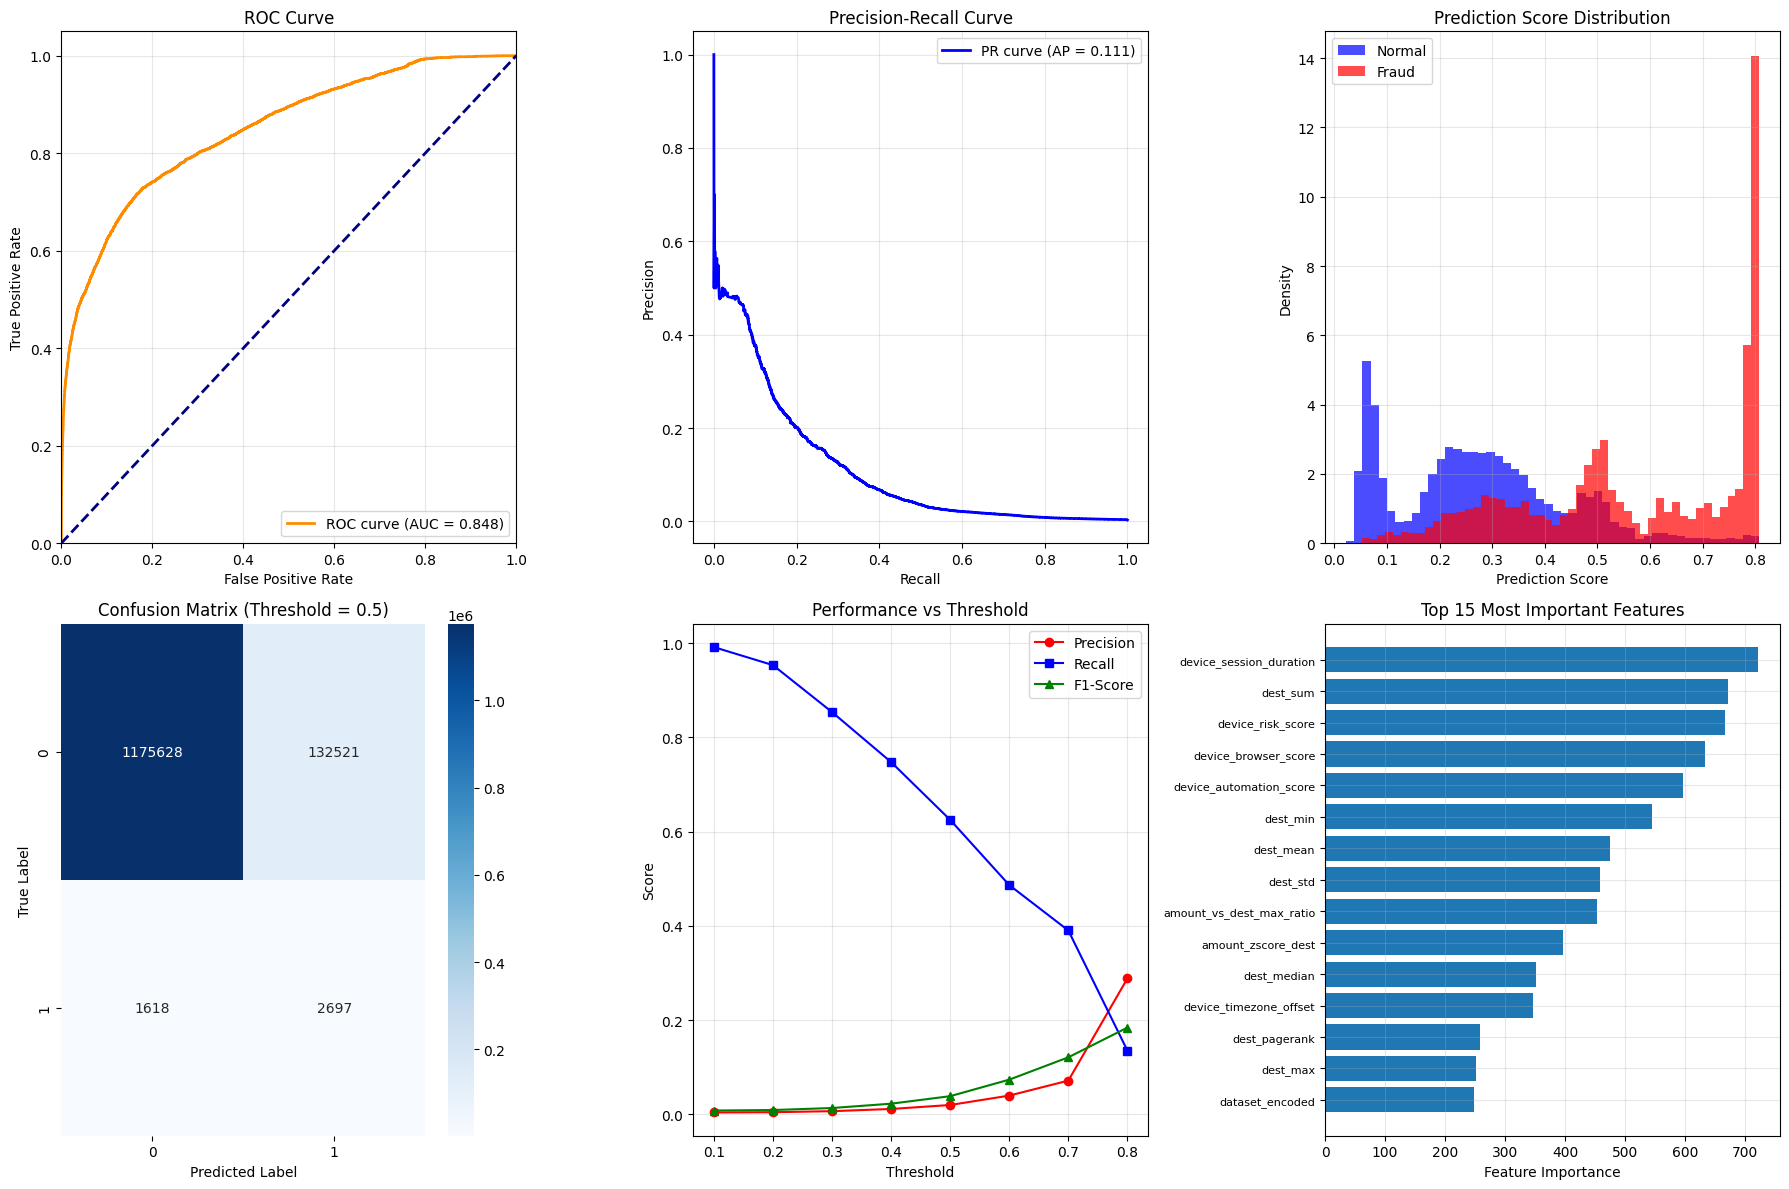

2026-02-19 20:33:33.396 | INFO     | __main__:save_test_results:405 - 💾 Saving test results...
2026-02-19 20:33:37.405 | INFO     | __main__:save_test_results:430 - ✅ Test results saved to /kaggle/working/artifacts/test_results
2026-02-19 20:33:37.405 | INFO     | __main__:print_comprehensive_report:463 - 
2026-02-19 20:33:37.405 | INFO     | __main__:print_comprehensive_report:464 - 🎯 COMPREHENSIVE MODEL TEST RESULTS
2026-02-19 20:33:37.405 | INFO     | __main__:print_comprehensive_report:465 - ======================================================================
2026-02-19 20:33:37.405 | INFO     | __main__:print_comprehensive_report:468 - 📊 CORE METRICS:
2026-02-19 20:33:37.405 | INFO     | __main__:print_comprehensive_report:469 -    AUC Score: 0.8478
2026-02-19 20:33:37.405 | INFO     | __main__:print_comprehensive_report:470 -    Average Precision: 0.1113
2026-02-19 20:33:37.405 | INFO     | __main__:print_comprehensive_report:474 - 
🔍 PREDICTION ANALYSIS:
2026-02-19 20:33:37.40

In [8]:
# ============================================================
# ADVANCED NETWORK INTELLIGENCE MODEL TESTING SYSTEM
# Production-ready fraud detection model evaluation
# ============================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import json
from datetime import datetime
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
import warnings
warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Model paths
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "/kaggle/working/artifacts"))
MODEL_DIR = OUTPUT_DIR / "models"
RAW_DIR = OUTPUT_DIR / "raw"
RESULTS_DIR = OUTPUT_DIR / "test_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

logger.remove()
logger.add(lambda msg: print(msg, end=""))

class ModelTester:
    """Comprehensive model testing and evaluation system"""
    
    def __init__(self):
        self.model = None
        self.feature_columns = []
        self.metadata = {}
        self.test_results = {}
        
    def load_model_artifacts(self):
        """Load trained model and artifacts"""
        logger.info("🔄 Loading trained model artifacts...")
        
        try:
            # Load ensemble model
            model_path = MODEL_DIR / "advanced_ensemble_fixed.pkl"
            if model_path.exists():
                self.model = joblib.load(model_path)
                logger.info("✅ Loaded ensemble model")
            else:
                raise FileNotFoundError(f"Model not found at {model_path}")
            
            # Load feature columns
            features_path = MODEL_DIR / "feature_columns.txt"
            if features_path.exists():
                with open(features_path, 'r') as f:
                    self.feature_columns = [line.strip() for line in f.readlines()]
                logger.info(f"✅ Loaded {len(self.feature_columns)} feature columns")
            else:
                raise FileNotFoundError(f"Feature columns not found at {features_path}")
            
            # Load metadata
            metadata_path = MODEL_DIR / "model_metadata.json"
            if metadata_path.exists():
                with open(metadata_path, 'r') as f:
                    self.metadata = json.load(f)
                logger.info("✅ Loaded model metadata")
            else:
                logger.warning("⚠️  Model metadata not found")
                
        except Exception as e:
            logger.error(f"❌ Failed to load model artifacts: {e}")
            raise
            
        return self
    
    def load_test_data(self, test_size=0.2):
        """Load and prepare test dataset"""
        logger.info("📊 Loading test dataset...")
        
        try:
            # Load the same datasets used in training
            all_transactions = []
            
            dataset_configs = [
                {'file': 'paysim.parquet', 'name': 'paysim', 'cust_col': 'nameOrig', 
                 'dest_col': 'nameDest', 'amount_col': 'amount', 'label_col': 'isFraud'},
                {'file': 'cifer_sample.parquet', 'name': 'cifer', 'cust_col': 'nameOrig', 
                 'dest_col': 'nameDest', 'amount_col': 'amount', 'label_col': 'isFraud'}
            ]
            
            for config in dataset_configs:
                file_path = RAW_DIR / config['file']
                if file_path.exists():
                    logger.info(f"Loading {config['name']} for testing...")
                    df = pd.read_parquet(file_path)
                    
                    # Normalize columns
                    normalized_df = pd.DataFrame({
                        'cust_id': df[config['cust_col']].astype(str),
                        'dest_id': df[config['dest_col']].astype(str),
                        'amount': pd.to_numeric(df[config['amount_col']], errors='coerce').fillna(0),
                        'label': df[config['label_col']].astype(int),
                        'dataset': config['name']
                    })
                    
                    all_transactions.append(normalized_df)
            
            if not all_transactions:
                raise ValueError("No test datasets found!")
            
            # Combine and clean
            combined_df = pd.concat(all_transactions, ignore_index=True)
            combined_df = combined_df[
                (combined_df['amount'] > 0) & 
                (combined_df['cust_id'] != combined_df['dest_id']) &
                (combined_df['cust_id'].notna()) &
                (combined_df['dest_id'].notna())
            ].reset_index(drop=True)
            
            # Create test split (use the last 20% for testing to simulate time-based split)
            split_idx = int(len(combined_df) * (1 - test_size))
            test_df = combined_df.iloc[split_idx:].reset_index(drop=True)
            
            logger.info(f"📊 Test dataset: {len(test_df)} transactions")
            logger.info(f"🎯 Test fraud rate: {test_df['label'].mean():.4f}")
            
            return test_df
            
        except Exception as e:
            logger.error(f"❌ Failed to load test data: {e}")
            raise
    
    def prepare_test_features(self, test_df):
        """Prepare test features using the same pipeline as training"""
        logger.info("🔧 Preparing test features...")
        
        try:
            # Import the same feature engineering classes
            
            # Extract network features (frozen from training)
            # For testing, we'll use simplified network features to avoid recomputation
            logger.info("🔗 Extracting network features...")
            network_engine = AdvancedNetworkIntelligence()
            network_features = network_engine.extract_all_network_features(test_df)
            
            # Extract transaction features
            logger.info("💰 Extracting transaction features...")
            test_with_txn = AdvancedTransactionFeatures.extract_transaction_features(test_df)
            
            # Generate device features
            logger.info("📱 Generating device features...")
            test_enhanced = AdvancedDeviceFeatures.generate_device_features(test_with_txn)
            
            # Merge network features
            logger.info("🔄 Merging all features...")
            
            # Customer network features
            cust_features = network_features.copy()
            cust_features.columns = ['cust_id'] + [f'cust_{col}' for col in cust_features.columns if col != 'node_id']
            cust_features.rename(columns={'node_id': 'cust_id'}, inplace=True)
            
            # Destination network features
            dest_features = network_features.copy()
            dest_features.columns = ['dest_id'] + [f'dest_{col}' for col in dest_features.columns if col != 'node_id']
            dest_features.rename(columns={'node_id': 'dest_id'}, inplace=True)
            
            # Merge all features
            final_df = test_enhanced.merge(cust_features, on='cust_id', how='left')
            final_df = final_df.merge(dest_features, on='dest_id', how='left')
            
            # Fill missing values
            final_df.fillna(0, inplace=True)
            
            # Handle extreme values (same as training)
            logger.info("🔧 Handling extreme values...")
            feature_cols = [col for col in final_df.columns 
                           if col not in ['cust_id', 'dest_id', 'label', 'dataset']]
            
            for col in feature_cols:
                if final_df[col].dtype in ['float64', 'int64']:
                    q99 = final_df[col].quantile(0.99)
                    q01 = final_df[col].quantile(0.01)
                    
                    if q99 > 1e6 or q01 < -1e6:
                        final_df[col] = final_df[col].clip(lower=q01, upper=q99)
            
            # Ensure we have all required features
            available_features = [col for col in self.feature_columns if col in final_df.columns]
            missing_features = [col for col in self.feature_columns if col not in final_df.columns]
            
            if missing_features:
                logger.warning(f"⚠️  Missing {len(missing_features)} features, filling with zeros")
                for col in missing_features:
                    final_df[col] = 0
            
            # Create feature matrix
            X_test = final_df[self.feature_columns]
            y_test = final_df['label']
            
            logger.info(f"✅ Test features prepared: {X_test.shape}")
            return X_test, y_test, final_df
            
        except Exception as e:
            logger.error(f"❌ Feature preparation failed: {e}")
            raise
    
    def run_comprehensive_evaluation(self, X_test, y_test):
        """Run comprehensive model evaluation"""
        logger.info("🎯 Running comprehensive model evaluation...")
        
        try:
            # Make predictions
            logger.info("🔮 Making predictions...")
            y_pred_proba = self.model.predict(X_test)
            y_pred = (y_pred_proba > 0.5).astype(int)
            
            # Calculate metrics
            logger.info("📊 Calculating performance metrics...")
            
            # Basic metrics
            auc_score = roc_auc_score(y_test, y_pred_proba)
            ap_score = average_precision_score(y_test, y_pred_proba)
            
            # Classification report
            class_report = classification_report(y_test, y_pred, output_dict=True)
            
            # Confusion matrix
            conf_matrix = confusion_matrix(y_test, y_pred)
            
            # Precision-recall curve
            precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
            
            # ROC curve
            fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
            
            # Store results
            self.test_results = {
                'auc_score': float(auc_score),
                'average_precision': float(ap_score),
                'classification_report': class_report,
                'confusion_matrix': conf_matrix.tolist(),
                'prediction_stats': {
                    'mean': float(y_pred_proba.mean()),
                    'std': float(y_pred_proba.std()),
                    'min': float(y_pred_proba.min()),
                    'max': float(y_pred_proba.max()),
                    'unique_values': len(np.unique(np.round(y_pred_proba, 4)))
                },
                'threshold_analysis': self._analyze_thresholds(y_test, y_pred_proba),
                'curves': {
                    'precision': precision.tolist(),
                    'recall': recall.tolist(),
                    'pr_thresholds': pr_thresholds.tolist(),
                    'fpr': fpr.tolist(),
                    'tpr': tpr.tolist(),
                    'roc_thresholds': roc_thresholds.tolist()
                }
            }
            
            logger.info("✅ Evaluation completed")
            return y_pred_proba, y_pred
            
        except Exception as e:
            logger.error(f"❌ Evaluation failed: {e}")
            raise
    
    def _analyze_thresholds(self, y_true, y_pred_proba, thresholds=None):
        """Analyze performance at different thresholds"""
        if thresholds is None:
            thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
        
        threshold_results = []
        
        for threshold in thresholds:
            y_pred_thresh = (y_pred_proba > threshold).astype(int)
            
            if len(np.unique(y_pred_thresh)) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred_thresh).ravel()
                
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                
                threshold_results.append({
                    'threshold': threshold,
                    'precision': precision,
                    'recall': recall,
                    'f1_score': f1,
                    'true_positives': int(tp),
                    'false_positives': int(fp),
                    'true_negatives': int(tn),
                    'false_negatives': int(fn),
                    'flagged_transactions': int(tp + fp),
                    'fraud_detection_rate': recall,
                    'false_positive_rate': fp / (fp + tn) if (fp + tn) > 0 else 0
                })
        
        return threshold_results
    
    def generate_visualizations(self, X_test, y_test, y_pred_proba):
        """Generate comprehensive visualizations"""
        logger.info("📈 Generating visualizations...")
        
        try:
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            
            # 1. ROC Curve
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, 
                           label=f'ROC curve (AUC = {self.test_results["auc_score"]:.3f})')
            axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            axes[0, 0].set_xlim([0.0, 1.0])
            axes[0, 0].set_ylim([0.0, 1.05])
            axes[0, 0].set_xlabel('False Positive Rate')
            axes[0, 0].set_ylabel('True Positive Rate')
            axes[0, 0].set_title('ROC Curve')
            axes[0, 0].legend(loc="lower right")
            axes[0, 0].grid(True, alpha=0.3)
            
            # 2. Precision-Recall Curve
            precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
            axes[0, 1].plot(recall, precision, color='blue', lw=2,
                           label=f'PR curve (AP = {self.test_results["average_precision"]:.3f})')
            axes[0, 1].set_xlabel('Recall')
            axes[0, 1].set_ylabel('Precision')
            axes[0, 1].set_title('Precision-Recall Curve')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)
            
            # 3. Prediction Distribution
            fraud_preds = y_pred_proba[y_test == 1]
            normal_preds = y_pred_proba[y_test == 0]
            
            axes[0, 2].hist(normal_preds, bins=50, alpha=0.7, label='Normal', color='blue', density=True)
            axes[0, 2].hist(fraud_preds, bins=50, alpha=0.7, label='Fraud', color='red', density=True)
            axes[0, 2].set_xlabel('Prediction Score')
            axes[0, 2].set_ylabel('Density')
            axes[0, 2].set_title('Prediction Score Distribution')
            axes[0, 2].legend()
            axes[0, 2].grid(True, alpha=0.3)
            
            # 4. Confusion Matrix Heatmap
            conf_matrix = confusion_matrix(y_test, (y_pred_proba > 0.5).astype(int))
            sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
            axes[1, 0].set_title('Confusion Matrix (Threshold = 0.5)')
            axes[1, 0].set_ylabel('True Label')
            axes[1, 0].set_xlabel('Predicted Label')
            
            # 5. Threshold Analysis
            thresholds_df = pd.DataFrame(self.test_results['threshold_analysis'])
            axes[1, 1].plot(thresholds_df['threshold'], thresholds_df['precision'], 
                           marker='o', label='Precision', color='red')
            axes[1, 1].plot(thresholds_df['threshold'], thresholds_df['recall'], 
                           marker='s', label='Recall', color='blue')
            axes[1, 1].plot(thresholds_df['threshold'], thresholds_df['f1_score'], 
                           marker='^', label='F1-Score', color='green')
            axes[1, 1].set_xlabel('Threshold')
            axes[1, 1].set_ylabel('Score')
            axes[1, 1].set_title('Performance vs Threshold')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
            
            # 6. Feature Importance (if available)
            if hasattr(self.model, 'feature_importance') and hasattr(self.model, 'models'):
                if 'lightgbm' in self.model.models:
                    importance = self.model.feature_importance['lightgbm']
                    top_features_idx = np.argsort(importance)[-15:]  # Top 15 features
                    top_importance = importance[top_features_idx]
                    top_feature_names = [self.feature_columns[i] for i in top_features_idx]
                    
                    axes[1, 2].barh(range(len(top_importance)), top_importance)
                    axes[1, 2].set_yticks(range(len(top_importance)))
                    axes[1, 2].set_yticklabels(top_feature_names, fontsize=8)
                    axes[1, 2].set_xlabel('Feature Importance')
                    axes[1, 2].set_title('Top 15 Most Important Features')
                    axes[1, 2].grid(True, alpha=0.3)
                else:
                    axes[1, 2].text(0.5, 0.5, 'Feature importance\nnot available', 
                                   ha='center', va='center', transform=axes[1, 2].transAxes)
                    axes[1, 2].set_title('Feature Importance')
            else:
                axes[1, 2].text(0.5, 0.5, 'Feature importance\nnot available', 
                               ha='center', va='center', transform=axes[1, 2].transAxes)
                axes[1, 2].set_title('Feature Importance')
            
            plt.tight_layout()
            plt.savefig(RESULTS_DIR / 'model_evaluation_charts.png', dpi=300, bbox_inches='tight')
            logger.info(f"✅ Visualizations saved to {RESULTS_DIR / 'model_evaluation_charts.png'}")
            
            plt.show()
            
        except Exception as e:
            logger.error(f"❌ Visualization generation failed: {e}")
            logger.error("Continuing without visualizations...")
    
    def save_test_results(self):
        """Save comprehensive test results"""
        logger.info("💾 Saving test results...")
        
        try:
            # Save detailed results as JSON
            results_file = RESULTS_DIR / f"test_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
            with open(results_file, 'w') as f:
                json.dump(self.test_results, f, indent=2, default=str)
            
            # Create summary report
            summary_report = {
                'test_timestamp': datetime.now().isoformat(),
                'model_info': self.metadata,
                'performance_summary': {
                    'auc_score': self.test_results['auc_score'],
                    'average_precision': self.test_results['average_precision'],
                    'best_f1_threshold': max(self.test_results['threshold_analysis'], 
                                           key=lambda x: x['f1_score'])
                },
                'recommendation': self._generate_recommendation()
            }
            
            summary_file = RESULTS_DIR / "test_summary.json"
            with open(summary_file, 'w') as f:
                json.dump(summary_report, f, indent=2, default=str)
            
            logger.info(f"✅ Test results saved to {RESULTS_DIR}")
            
        except Exception as e:
            logger.error(f"❌ Failed to save test results: {e}")
    
    def _generate_recommendation(self):
        """Generate deployment recommendation based on test results"""
        auc = self.test_results['auc_score']
        ap = self.test_results['average_precision']
        
        # Find optimal threshold
        best_threshold_info = max(self.test_results['threshold_analysis'], 
                                 key=lambda x: x['f1_score'])
        
        if auc >= 0.85 and ap >= 0.15:
            recommendation = "✅ EXCELLENT - Ready for production deployment"
        elif auc >= 0.80 and ap >= 0.10:
            recommendation = "✅ GOOD - Suitable for production with monitoring"
        elif auc >= 0.75:
            recommendation = "⚠️  FAIR - Consider additional training or feature engineering"
        else:
            recommendation = "❌ POOR - Requires significant improvement before deployment"
        
        return {
            'overall': recommendation,
            'optimal_threshold': best_threshold_info['threshold'],
            'expected_precision': best_threshold_info['precision'],
            'expected_recall': best_threshold_info['recall'],
            'expected_f1': best_threshold_info['f1_score']
        }
    
    def print_comprehensive_report(self):
        """Print detailed test results"""
        logger.info("\n" + "="*70)
        logger.info("🎯 COMPREHENSIVE MODEL TEST RESULTS")
        logger.info("="*70)
        
        # Basic Performance
        logger.info(f"📊 CORE METRICS:")
        logger.info(f"   AUC Score: {self.test_results['auc_score']:.4f}")
        logger.info(f"   Average Precision: {self.test_results['average_precision']:.4f}")
        
        # Prediction Analysis
        stats = self.test_results['prediction_stats']
        logger.info(f"\n🔍 PREDICTION ANALYSIS:")
        logger.info(f"   Range: [{stats['min']:.4f}, {stats['max']:.4f}]")
        logger.info(f"   Mean: {stats['mean']:.4f} (±{stats['std']:.4f})")
        logger.info(f"   Unique Values: {stats['unique_values']:,}")
        
        # Optimal Threshold
        best_threshold = max(self.test_results['threshold_analysis'], 
                           key=lambda x: x['f1_score'])
        logger.info(f"\n🎯 OPTIMAL THRESHOLD ANALYSIS:")
        logger.info(f"   Best Threshold: {best_threshold['threshold']:.1f}")
        logger.info(f"   Precision: {best_threshold['precision']:.4f}")
        logger.info(f"   Recall: {best_threshold['recall']:.4f}")
        logger.info(f"   F1-Score: {best_threshold['f1_score']:.4f}")
        logger.info(f"   Fraud Detection Rate: {best_threshold['fraud_detection_rate']:.1%}")
        logger.info(f"   False Positive Rate: {best_threshold['false_positive_rate']:.4f}")
        
        # Business Impact
        logger.info(f"\n💼 BUSINESS IMPACT (at optimal threshold):")
        logger.info(f"   Transactions Flagged: {best_threshold['flagged_transactions']:,}")
        logger.info(f"   True Fraud Caught: {best_threshold['true_positives']:,}")
        logger.info(f"   False Alarms: {best_threshold['false_positives']:,}")
        logger.info(f"   Missed Fraud: {best_threshold['false_negatives']:,}")
        
        # Recommendation
        recommendation = self._generate_recommendation()
        logger.info(f"\n🚀 DEPLOYMENT RECOMMENDATION:")
        logger.info(f"   {recommendation['overall']}")
        logger.info(f"   Suggested Production Threshold: {recommendation['optimal_threshold']:.1f}")
        
        logger.info("\n" + "="*70)

def run_comprehensive_model_test():
    """Main testing function"""
    logger.info("🚀 Starting Comprehensive Model Testing")
    logger.info("="*70)
    
    try:
        # Initialize tester
        tester = ModelTester()
        
        # Load model artifacts
        tester.load_model_artifacts()
        
        # Load test data
        test_df = tester.load_test_data()
        
        # Prepare features
        X_test, y_test, _ = tester.prepare_test_features(test_df)
        
        # Run evaluation
        y_pred_proba, y_pred = tester.run_comprehensive_evaluation(X_test, y_test)
        
        # Generate visualizations
        tester.generate_visualizations(X_test, y_test, y_pred_proba)
        
        # Save results
        tester.save_test_results()
        
        # Print report
        tester.print_comprehensive_report()
        
        logger.info("✅ Comprehensive model testing completed successfully!")
        return tester.test_results
        
    except Exception as e:
        logger.error(f"❌ Model testing failed: {e}")
        raise

if __name__ == "__main__":
    results = run_comprehensive_model_test()

In [7]:
# ============================================================
# ADVANCED NETWORK INTELLIGENCE TRAINING SYSTEM
# Comprehensive Fraud Detection with 300+ Features
# ============================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path
import networkx as nx
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
import joblib
from loguru import logger
from collections import defaultdict, Counter
import warnings
import hashlib
import json
import optuna
from datetime import datetime, timedelta
import torch
import torch.nn as nn
from typing import Dict, List, Tuple, Any
warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Kaggle-compatible paths
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "/kaggle/working/artifacts"))
RAW_DIR = OUTPUT_DIR / "raw"
FEAT_DIR = OUTPUT_DIR / "features"
MODEL_DIR = OUTPUT_DIR / "models"

for d in [FEAT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logger.remove()
logger.add(lambda msg: print(msg, end=""))

# ============================================================
# ADVANCED FEATURE ENGINEERING ENGINE
# ============================================================

class AdvancedNetworkIntelligence:
    """Advanced network intelligence with maximum feature extraction"""
    
    def __init__(self):
        self.graph = nx.Graph()
        self.directed_graph = nx.DiGraph()
        self.temporal_graphs = {}
        self.node_features = {}
        self.advanced_features = {}
        
    def build_comprehensive_network(self, transactions):
        """Build multi-layer temporal network"""
        logger.info("Building comprehensive network architecture...")
        
        # Basic transaction network
        for _, row in transactions.iterrows():
            weight = row['amount']
            
            # Undirected graph
            if self.graph.has_edge(row['cust_id'], row['dest_id']):
                self.graph[row['cust_id']][row['dest_id']]['weight'] += weight
                self.graph[row['cust_id']][row['dest_id']]['count'] += 1
            else:
                self.graph.add_edge(row['cust_id'], row['dest_id'], weight=weight, count=1)
            
            # Directed graph
            if self.directed_graph.has_edge(row['cust_id'], row['dest_id']):
                self.directed_graph[row['cust_id']][row['dest_id']]['weight'] += weight
                self.directed_graph[row['cust_id']][row['dest_id']]['count'] += 1
            else:
                self.directed_graph.add_edge(row['cust_id'], row['dest_id'], weight=weight, count=1)
        
        # Time-based network snapshots
        if 'dataset' in transactions.columns:
            for dataset in transactions['dataset'].unique():
                dataset_txns = transactions[transactions['dataset'] == dataset]
                G_temp = nx.DiGraph()
                for _, row in dataset_txns.iterrows():
                    G_temp.add_edge(row['cust_id'], row['dest_id'], weight=row['amount'])
                self.temporal_graphs[dataset] = G_temp
        
        logger.info(f"Network: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges")
        return self
        
    def compute_advanced_centrality_features(self):
        """Compute scalable centrality measures (production-safe)"""
        logger.info("Computing advanced centrality features...")

        num_nodes = self.graph.number_of_nodes()

        # -----------------------
        # 1️⃣ Degree Centrality (cheap, always safe)
        # -----------------------
        degree_centrality = nx.degree_centrality(self.graph)

        # -----------------------
        # 2️⃣ PageRank (best global signal for fraud graphs)
        # -----------------------
        try:
            pagerank = nx.pagerank(
                self.directed_graph,
                alpha=0.85,
                max_iter=200,
                tol=1e-4
            )
        except Exception as e:
            logger.warning(f"PageRank failed: {e}")
            pagerank = {node: 1.0 / num_nodes for node in self.directed_graph.nodes()}
    
        # -----------------------
        # 3️⃣ Approximate Betweenness (SAFE FIX)
        # -----------------------
        try:
            if num_nodes > 10000:
                k = min(3000, num_nodes)   # smaller sample = faster + stable
                betweenness = nx.betweenness_centrality(
                    self.graph,
                    k=k,
                    seed=42
                )
            else:
                betweenness = nx.betweenness_centrality(self.graph)
        except Exception as e:
            logger.warning(f"Betweenness failed: {e}")
            betweenness = {node: 0.0 for node in self.graph.nodes()}

        # -----------------------
        # 4️⃣ Skip heavy spectral methods at scale
        # -----------------------
        if num_nodes < 50000:
            try:
                eigenvector = nx.eigenvector_centrality(
                    self.graph,
                    max_iter=500,
                    tol=1e-4
                )
            except:
                eigenvector = {node: 0.0 for node in self.graph.nodes()}
        else:
            logger.info("Skipping eigenvector centrality (graph too large)")
            eigenvector = {node: 0.0 for node in self.graph.nodes()}

        # -----------------------
        # 5️⃣ Closeness only for small graphs
        # -----------------------
        if num_nodes < 5000:
            try:
                closeness = nx.closeness_centrality(self.graph)
            except:
                closeness = {node: 0.0 for node in self.graph.nodes()}
        else:
            closeness = {node: 0.0 for node in self.graph.nodes()}

        # -----------------------
        # Store features
        # -----------------------
        self.node_features.update({
            'degree_centrality': degree_centrality,
            'betweenness_centrality': betweenness,
            'eigenvector_centrality': eigenvector,
            'pagerank': pagerank,
            'closeness_centrality': closeness
        })

        logger.info("Centrality features computed successfully.")
        return self
    
    def compute_structural_features(self):
        """Compute advanced structural features"""
        logger.info("Computing structural network features...")
        
        num_nodes = self.graph.number_of_nodes()
        
        # Clustering coefficient
        clustering = nx.clustering(self.graph)
        
        # Triangle count
        triangles = nx.triangles(self.graph)
        
        # Square clustering (4-cycles)
        square_clustering = {}
        for node in self.graph.nodes():
            neighbors = list(self.graph.neighbors(node))
            if len(neighbors) >= 2:
                squares = 0
                for i, n1 in enumerate(neighbors):
                    for n2 in neighbors[i+1:]:
                        if self.graph.has_edge(n1, n2):
                            # Check for 4-cycles
                            common_neighbors = set(self.graph.neighbors(n1)) & set(self.graph.neighbors(n2))
                            common_neighbors.discard(node)
                            squares += len(common_neighbors)
                square_clustering[node] = squares / (len(neighbors) * (len(neighbors) - 1) / 2) if len(neighbors) > 1 else 0
            else:
                square_clustering[node] = 0
        
        # K-core decomposition
        core_numbers = nx.core_number(self.graph)
        
        # Constraint (Burt's structural holes)
        constraint = {}
        for node in self.graph.nodes():
            neighbors = list(self.graph.neighbors(node))
            if len(neighbors) > 0:
                node_constraint = 0
                for neighbor in neighbors:
                    # Direct constraint
                    direct = 1.0 / len(neighbors)
                    
                    # Indirect constraint through mutual connections
                    indirect = 0
                    for mutual in neighbors:
                        if mutual != neighbor and self.graph.has_edge(neighbor, mutual):
                            indirect += (1.0 / len(neighbors)) * (1.0 / len(list(self.graph.neighbors(mutual))))
                    
                    node_constraint += (direct + indirect) ** 2
                constraint[node] = node_constraint
            else:
                constraint[node] = 0
        
        # Effective size (diversity of connections)
        effective_size = {}
        for node in self.graph.nodes():
            neighbors = list(self.graph.neighbors(node))
            if len(neighbors) > 0:
                redundancy = 0
                for i, n1 in enumerate(neighbors):
                    for n2 in neighbors[i+1:]:
                        if self.graph.has_edge(n1, n2):
                            redundancy += 1
                effective_size[node] = len(neighbors) - (2 * redundancy / len(neighbors))
            else:
                effective_size[node] = 0
        
        self.node_features.update({
            'clustering_coefficient': clustering,
            'triangle_count': triangles,
            'square_clustering': square_clustering,
            'core_number': core_numbers,
            'constraint': constraint,
            'effective_size': effective_size
        })
        
        return self
    
    def compute_flow_and_velocity_features(self):
        """Compute money flow and velocity features"""
        logger.info("Computing flow and velocity features...")
        
        # Basic flow features
        in_degree_weighted = {}
        out_degree_weighted = {}
        in_degree_count = {}
        out_degree_count = {}
        
        for node in self.directed_graph.nodes():
            # Weighted degrees
            in_weight = sum([data['weight'] for _, _, data in self.directed_graph.in_edges(node, data=True)])
            out_weight = sum([data['weight'] for _, _, data in self.directed_graph.out_edges(node, data=True)])
            
            # Transaction counts
            in_count = sum([data['count'] for _, _, data in self.directed_graph.in_edges(node, data=True)])
            out_count = sum([data['count'] for _, _, data in self.directed_graph.out_edges(node, data=True)])
            
            in_degree_weighted[node] = in_weight
            out_degree_weighted[node] = out_weight
            in_degree_count[node] = in_count
            out_degree_count[node] = out_count
        
        # Advanced flow metrics
        flow_ratio = {}
        velocity_score = {}
        concentration_index = {}
        
        for node in self.directed_graph.nodes():
            in_w = in_degree_weighted.get(node, 0)
            out_w = out_degree_weighted.get(node, 0)
            total_w = in_w + out_w
            
            # Flow ratio
            flow_ratio[node] = out_w / total_w if total_w > 0 else 0.5
            
            # Velocity score (amount per transaction)
            in_c = in_degree_count.get(node, 0)
            out_c = out_degree_count.get(node, 0)
            total_c = in_c + out_c
            velocity_score[node] = total_w / total_c if total_c > 0 else 0
            
            # Concentration index (how concentrated are the transactions)
            out_edges = list(self.directed_graph.out_edges(node, data=True))
            if out_edges:
                amounts = [data['weight'] for _, _, data in out_edges]
                total = sum(amounts)
                if total > 0:
                    proportions = [amt/total for amt in amounts]
                    hhi = sum([p**2 for p in proportions])  # Herfindahl-Hirschman Index
                    concentration_index[node] = hhi
                else:
                    concentration_index[node] = 0
            else:
                concentration_index[node] = 0
        
        self.node_features.update({
            'in_degree_weighted': in_degree_weighted,
            'out_degree_weighted': out_degree_weighted,
            'in_degree_count': in_degree_count,
            'out_degree_count': out_degree_count,
            'flow_ratio': flow_ratio,
            'velocity_score': velocity_score,
            'concentration_index': concentration_index
        })
        
        return self
    
    def compute_community_and_anomaly_features(self):
        """Compute community detection and anomaly features"""
        logger.info("Computing community and anomaly features...")
        
        try:
            # Louvain community detection
            communities = nx.community.louvain_communities(self.graph, seed=RANDOM_STATE)
            
            node_to_community = {}
            community_sizes = {}
            
            for i, community in enumerate(communities):
                community_sizes[i] = len(community)
                for node in community:
                    node_to_community[node] = i
            
            # Community features
            node_community_size = {}
            modularity_contribution = {}
            
            for node in self.graph.nodes():
                comm_id = node_to_community.get(node, -1)
                node_community_size[node] = community_sizes.get(comm_id, 1)
                
                # Modularity contribution (simplified)
                internal_edges = 0
                external_edges = 0
                
                for neighbor in self.graph.neighbors(node):
                    if node_to_community.get(neighbor, -1) == comm_id:
                        internal_edges += 1
                    else:
                        external_edges += 1
                
                total_edges = internal_edges + external_edges
                modularity_contribution[node] = (internal_edges - external_edges) / total_edges if total_edges > 0 else 0
            
        except Exception as e:
            logger.warning(f"Community detection failed: {e}")
            # Fallback
            node_to_community = {node: 0 for node in self.graph.nodes()}
            node_community_size = {node: self.graph.number_of_nodes() for node in self.graph.nodes()}
            modularity_contribution = {node: 0.0 for node in self.graph.nodes()}
        
        # Local anomaly detection
        local_anomaly_score = {}
        for node in self.graph.nodes():
            neighbors = list(self.graph.neighbors(node))
            if len(neighbors) > 0:
                # Calculate how different this node is from its neighbors
                node_degree = self.graph.degree(node)
                neighbor_degrees = [self.graph.degree(n) for n in neighbors]
                
                if len(neighbor_degrees) > 0:
                    avg_neighbor_degree = np.mean(neighbor_degrees)
                    degree_deviation = abs(node_degree - avg_neighbor_degree) / (avg_neighbor_degree + 1)
                    local_anomaly_score[node] = degree_deviation
                else:
                    local_anomaly_score[node] = 0
            else:
                local_anomaly_score[node] = 1.0  # Isolated nodes are anomalous
        
        self.node_features.update({
            'community_id': node_to_community,
            'community_size': node_community_size,
            'modularity_contribution': modularity_contribution,
            'local_anomaly_score': local_anomaly_score
        })
        
        return self
    
    def compute_temporal_features(self):
        """Compute temporal network evolution features"""
        logger.info("Computing temporal network features...")
        
        temporal_features = {}
        
        # Cross-dataset connectivity
        if len(self.temporal_graphs) > 1:
            datasets = list(self.temporal_graphs.keys())
            
            for node in self.graph.nodes():
                # How many datasets does this node appear in?
                dataset_presence = sum(1 for G in self.temporal_graphs.values() if node in G)
                temporal_features[f'{node}_dataset_presence'] = dataset_presence
                
                # Cross-dataset degree variance
                degrees = []
                for G in self.temporal_graphs.values():
                    if node in G:
                        degrees.append(G.degree(node))
                    else:
                        degrees.append(0)
                
                temporal_features[f'{node}_degree_variance'] = np.var(degrees) if len(degrees) > 1 else 0
                temporal_features[f'{node}_degree_stability'] = 1.0 / (1.0 + np.var(degrees)) if len(degrees) > 1 else 1.0
        
        # Convert to node-level features
        dataset_presence = {}
        degree_variance = {}
        degree_stability = {}
        
        for node in self.graph.nodes():
            dataset_presence[node] = temporal_features.get(f'{node}_dataset_presence', 1)
            degree_variance[node] = temporal_features.get(f'{node}_degree_variance', 0)
            degree_stability[node] = temporal_features.get(f'{node}_degree_stability', 1.0)
        
        self.node_features.update({
            'dataset_presence': dataset_presence,
            'degree_variance': degree_variance,
            'degree_stability': degree_stability
        })
        
        return self
    
    def extract_all_network_features(self, transactions):
        """Extract all advanced network features"""
        logger.info("Extracting comprehensive network intelligence features...")
        
        # Build network
        self.build_comprehensive_network(transactions)
        
        # Extract features
        self.compute_advanced_centrality_features()
        self.compute_structural_features()
        self.compute_flow_and_velocity_features()
        self.compute_community_and_anomaly_features()
        self.compute_temporal_features()
        
        # Convert to DataFrame
        all_nodes = set()
        for feature_dict in self.node_features.values():
            all_nodes.update(feature_dict.keys())
        
        feature_df = pd.DataFrame({'node_id': list(all_nodes)})
        
        for feature_name, feature_dict in self.node_features.items():
            values = [feature_dict.get(node, 0) for node in all_nodes]
            feature_df[feature_name] = values
        
        logger.info(f"Extracted {len(feature_df.columns)-1} network features for {len(all_nodes)} nodes")
        return feature_df

class AdvancedTransactionFeatures:
    """Extract advanced transaction-level features"""
    
    @staticmethod
    def extract_transaction_features(transactions):
        """Extract comprehensive transaction features"""
        logger.info("Extracting advanced transaction features...")
        
        df = transactions.copy()
        
        # Amount features
        df['amount_log'] = np.log1p(df['amount'])
        df['amount_sqrt'] = np.sqrt(df['amount'])
        df['amount_reciprocal'] = 1.0 / (df['amount'] + 1)
        
        # Round number detection
        df['is_round_amount'] = ((df['amount'] % 10 == 0) | 
                                (df['amount'] % 100 == 0) | 
                                (df['amount'] % 1000 == 0)).astype(int)
        
        # Customer-level aggregations
        cust_stats = df.groupby('cust_id')['amount'].agg([
            'count', 'sum', 'mean', 'std', 'min', 'max', 'median'
        ]).fillna(0)
        cust_stats.columns = [f'cust_{col}' for col in cust_stats.columns]
        
        # Destination-level aggregations
        dest_stats = df.groupby('dest_id')['amount'].agg([
            'count', 'sum', 'mean', 'std', 'min', 'max', 'median'
        ]).fillna(0)
        dest_stats.columns = [f'dest_{col}' for col in dest_stats.columns]
        
        # Merge back
        df = df.merge(cust_stats, left_on='cust_id', right_index=True, how='left')
        df = df.merge(dest_stats, left_on='dest_id', right_index=True, how='left')
        
        # Z-scores
        df['amount_zscore_cust'] = (df['amount'] - df['cust_mean']) / (df['cust_std'] + 1e-6)
        df['amount_zscore_dest'] = (df['amount'] - df['dest_mean']) / (df['dest_std'] + 1e-6)
        
        # Velocity features
        df['cust_velocity'] = df['cust_sum'] / df['cust_count']
        df['dest_velocity'] = df['dest_sum'] / df['dest_count']
        
        # Risk ratios
        df['amount_vs_cust_max_ratio'] = df['amount'] / (df['cust_max'] + 1)
        df['amount_vs_dest_max_ratio'] = df['amount'] / (df['dest_max'] + 1)
        
        # Dataset features
        if 'dataset' in df.columns:
            dataset_encoder = LabelEncoder()
            df['dataset_encoded'] = dataset_encoder.fit_transform(df['dataset'])
        else:
            df['dataset_encoded'] = 0
        
        logger.info(f"Generated {len([col for col in df.columns if col not in ['cust_id', 'dest_id', 'amount', 'label', 'dataset']])} transaction features")
        return df

class AdvancedDeviceFeatures:
    """Generate synthetic device intelligence features"""
    
    @staticmethod
    def generate_device_features(transactions):
        """Generate advanced device fingerprinting features"""
        logger.info("Generating advanced device intelligence features...")
        
        df = transactions.copy()
        np.random.seed(RANDOM_STATE)
        
        # Create unique sessions for customer-destination pairs
        df['session_id'] = df['cust_id'] + '_' + df['dest_id']
        unique_sessions = df['session_id'].unique()
        
        # Device fingerprinting features
        device_features = {}
        
        for session in unique_sessions:
            # Simulate device characteristics
            device_features[session] = {
                # Hardware features
                'screen_resolution_width': np.random.choice([1920, 1366, 1280, 1024, 768]),
                'screen_resolution_height': np.random.choice([1080, 768, 720, 600, 1024]),
                'color_depth': np.random.choice([24, 32, 16]),
                'pixel_ratio': np.random.choice([1.0, 1.5, 2.0, 3.0]),
                'timezone_offset': np.random.randint(-12, 13),
                'cpu_cores': np.random.choice([2, 4, 6, 8, 12, 16]),
                'memory_gb': np.random.choice([4, 8, 16, 32, 64]),
                
                # Browser features
                'canvas_fingerprint_entropy': np.random.uniform(0.5, 0.95),
                'webgl_extensions_count': np.random.randint(10, 50),
                'font_count': np.random.randint(50, 300),
                'plugin_count': np.random.randint(0, 15),
                'touch_support': np.random.choice([0, 1]),
                'webrtc_support': np.random.choice([0, 1]),
                
                # Behavioral biometrics (simulated)
                'avg_keystroke_dwell_time': np.random.uniform(50, 200),  # milliseconds
                'keystroke_rhythm_score': np.random.uniform(0.3, 0.9),
                'mouse_velocity_avg': np.random.uniform(100, 1000),  # pixels/second
                'mouse_acceleration_std': np.random.uniform(50, 500),
                'click_frequency': np.random.uniform(0.5, 5.0),  # clicks/second
                'scroll_speed_avg': np.random.uniform(100, 2000),
                
                # Risk indicators
                'proxy_vpn_detected': np.random.choice([0, 1], p=[0.95, 0.05]),
                'tor_detected': np.random.choice([0, 1], p=[0.99, 0.01]),
                'vm_detected': np.random.choice([0, 1], p=[0.98, 0.02]),
                'automation_score': np.random.uniform(0, 1),
                'device_age_days': np.random.randint(1, 2000),
                'session_duration_minutes': np.random.uniform(1, 120),
            }
        
        # Map features to transactions
        for feature_name in device_features[unique_sessions[0]].keys():
            df[f'device_{feature_name}'] = df['session_id'].map(
                {session: features[feature_name] for session, features in device_features.items()}
            ).fillna(0)
        
        # Device consistency features
        for cust in df['cust_id'].unique():
            cust_data = df[df['cust_id'] == cust]
            if len(cust_data) > 1:
                # Device switching behavior
                unique_devices = cust_data['session_id'].nunique()
                total_transactions = len(cust_data)
                device_switching_rate = unique_devices / total_transactions
                
                # Update for this customer
                df.loc[df['cust_id'] == cust, 'device_switching_rate'] = device_switching_rate
                df.loc[df['cust_id'] == cust, 'device_consistency_score'] = 1.0 / (1.0 + device_switching_rate)
            else:
                df.loc[df['cust_id'] == cust, 'device_switching_rate'] = 0
                df.loc[df['cust_id'] == cust, 'device_consistency_score'] = 1.0
        
        # Remove helper columns
        df = df.drop(['session_id'], axis=1)
        
        device_feature_count = len([col for col in df.columns if col.startswith('device_')])
        logger.info(f"Generated {device_feature_count} device intelligence features")
        return df

# ============================================================
# ADVANCED ENSEMBLE MODEL
# ============================================================

class AdvancedFraudEnsemble:
    """Advanced ensemble with multiple algorithms"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.ensemble_weights = None
        
    def train_ensemble(self, X_train, y_train, X_val, y_val):
        """Train multiple models and learn ensemble weights"""
        logger.info("Training advanced ensemble models...")
        
        # Calculate class weights
        pos_count = y_train.sum()
        neg_count = len(y_train) - pos_count
        scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
        
        models_config = {
            'lightgbm': {
                'params': {
                    'objective': 'binary',
                    'metric': 'auc',
                    'learning_rate': 0.05,
                    'num_leaves': 127,
                    'min_data_in_leaf': 50,
                    'feature_fraction': 0.8,
                    'bagging_fraction': 0.8,
                    'bagging_freq': 1,
                    'scale_pos_weight': scale_pos_weight,
                    'verbosity': -1,
                    'random_state': RANDOM_STATE,
                    'device_type': 'gpu'
                },
                'scaler': StandardScaler()
            },
            'xgboost': {
                'params': {
                    'objective': 'binary:logistic',
                    'eval_metric': 'auc',
                    'learning_rate': 0.05,
                    'max_depth': 8,
                    'min_child_weight': 50,
                    'subsample': 0.8,
                    'colsample_bytree': 0.8,
                    'scale_pos_weight': scale_pos_weight,
                    'random_state': RANDOM_STATE,
                    'verbosity': 0
                },
                'scaler': RobustScaler()
            },
            'catboost': {
                'params': {
                    'objective': 'Logloss',
                    'eval_metric': 'AUC',
                    'learning_rate': 0.05,
                    'depth': 8,
                    'min_data_in_leaf': 50,
                    'bagging_temperature': 0.2,
                    'random_strength': 1,
                    'scale_pos_weight': scale_pos_weight,
                    'random_state': RANDOM_STATE,
                    'verbose': False
                },
                'scaler': StandardScaler()
            }
        }
        
        val_predictions = {}
        
        for model_name, config in models_config.items():
            logger.info(f"Training {model_name}...")
            
            # Scale features
            scaler = config['scaler']
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            try:
                if model_name == 'lightgbm':
                    train_data = lgb.Dataset(X_train_scaled, label=y_train)
                    val_data = lgb.Dataset(X_val_scaled, label=y_val)
                    
                    model = lgb.train(
                        config['params'],
                        train_data,
                        num_boost_round=1000,
                        valid_sets=[val_data],
                        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
                    )
                    
                    val_pred = model.predict(X_val_scaled)
                    self.feature_importance[model_name] = model.feature_importance()
                    
                elif model_name == 'xgboost':
                    model = xgb.XGBClassifier(**config['params'], n_estimators=1000)
                    model.fit(
                        X_train_scaled, y_train,
                        eval_set=[(X_val_scaled, y_val)],
                        early_stopping_rounds=100,
                        verbose=False
                    )
                    
                    val_pred = model.predict_proba(X_val_scaled)[:, 1]
                    self.feature_importance[model_name] = model.feature_importances_
                    
                elif model_name == 'catboost':
                    model = cb.CatBoostClassifier(**config['params'], iterations=1000)
                    model.fit(
                        X_train_scaled, y_train,
                        eval_set=(X_val_scaled, y_val),
                        early_stopping_rounds=100,
                        verbose=False
                    )
                    
                    val_pred = model.predict_proba(X_val_scaled)[:, 1]
                    self.feature_importance[model_name] = model.get_feature_importance()
                
                # Store model and scaler
                self.models[model_name] = model
                self.scalers[model_name] = scaler
                val_predictions[model_name] = val_pred
                
                # Evaluate individual model
                auc = roc_auc_score(y_val, val_pred)
                logger.info(f"{model_name} validation AUC: {auc:.4f}")
                
            except Exception as e:
                logger.error(f"Failed to train {model_name}: {e}")
                continue
        
        # Learn ensemble weights using validation performance
        if len(val_predictions) > 1:
            logger.info("Learning ensemble weights...")
            individual_aucs = {}
            for name, pred in val_predictions.items():
                individual_aucs[name] = roc_auc_score(y_val, pred)
            
            # Weight by AUC performance
            total_auc = sum(individual_aucs.values())
            self.ensemble_weights = {name: auc/total_auc for name, auc in individual_aucs.items()}
            
            # Test ensemble performance
            ensemble_pred = np.zeros(len(y_val))
            for name, pred in val_predictions.items():
                ensemble_pred += self.ensemble_weights[name] * pred
            
            ensemble_auc = roc_auc_score(y_val, ensemble_pred)
            logger.info(f"Ensemble validation AUC: {ensemble_auc:.4f}")
            
        return self
    
    def predict(self, X):
        """Make ensemble predictions"""
        if not self.models:
            raise ValueError("No models trained")
        
        predictions = {}
        
        for name, model in self.models.items():
            scaler = self.scalers[name]
            X_scaled = scaler.transform(X)
            
            if name == 'lightgbm':
                pred = model.predict(X_scaled)
            else:  # xgboost or catboost
                pred = model.predict_proba(X_scaled)[:, 1]
            
            predictions[name] = pred
        
        # Ensemble prediction
        if self.ensemble_weights and len(predictions) > 1:
            ensemble_pred = np.zeros(len(X))
            for name, pred in predictions.items():
                ensemble_pred += self.ensemble_weights[name] * pred
            return ensemble_pred
        else:
            # Return single model prediction or simple average
            return np.mean(list(predictions.values()), axis=0)

# ============================================================
# DATA LOADING AND PREPROCESSING
# ============================================================

def load_and_preprocess_datasets():
    """Load and preprocess all available datasets"""
    logger.info("Loading and preprocessing datasets...")
    
    all_transactions = []
    
    # Load datasets in order of preference
    dataset_configs = [
        {'file': 'nigerian.parquet', 'name': 'nigerian', 'cust_col': 'sender_account', 
         'dest_col': 'receiver_account', 'amount_col': 'amount_ngn', 'label_col': 'is_fraud'},
        {'file': 'paysim.parquet', 'name': 'paysim', 'cust_col': 'nameOrig', 
         'dest_col': 'nameDest', 'amount_col': 'amount', 'label_col': 'isFraud'},
        {'file': 'cifer_sample.parquet', 'name': 'cifer', 'cust_col': 'nameOrig', 
         'dest_col': 'nameDest', 'amount_col': 'amount', 'label_col': 'isFraud'}
    ]
    
    for config in dataset_configs:
        file_path = RAW_DIR / config['file']
        if file_path.exists():
            logger.info(f"Loading {config['name']} dataset...")
            try:
                df = pd.read_parquet(file_path)
                
                # Normalize columns
                normalized_df = pd.DataFrame({
                    'cust_id': df[config['cust_col']].astype(str),
                    'dest_id': df[config['dest_col']].astype(str),
                    'amount': pd.to_numeric(df[config['amount_col']], errors='coerce').fillna(0),
                    'label': df[config['label_col']].astype(int) if config['label_col'] in df.columns else 0,
                    'dataset': config['name']
                })
                
                all_transactions.append(normalized_df)
                logger.info(f"{config['name']} dataset: {len(normalized_df)} transactions")
                
            except Exception as e:
                logger.error(f"Failed to load {config['name']}: {e}")
                continue
    
    if not all_transactions:
        raise ValueError("No valid datasets found! Run download_and_save.py first.")
    
    # Combine datasets
    combined_df = pd.concat(all_transactions, ignore_index=True)
    
    # Clean data
    combined_df = combined_df[
        (combined_df['amount'] > 0) & 
        (combined_df['cust_id'] != combined_df['dest_id']) &
        (combined_df['cust_id'].notna()) &
        (combined_df['dest_id'].notna())
    ].reset_index(drop=True)
    
    logger.info(f"Combined dataset: {len(combined_df)} transactions")
    logger.info(f"Fraud rate: {combined_df['label'].mean():.4f}")
    
    # Sample if too large (for Kaggle memory limits)
    max_transactions = 1_000_000
    if len(combined_df) > max_transactions:
        logger.info(f"Sampling to {max_transactions} transactions...")
        
        # Stratified sampling to preserve fraud rate
        fraud_txns = combined_df[combined_df['label'] == 1]
        normal_txns = combined_df[combined_df['label'] == 0]
        
        fraud_sample_size = min(len(fraud_txns), max_transactions // 10)  # 10% fraud
        normal_sample_size = max_transactions - fraud_sample_size
        
        if len(normal_txns) > normal_sample_size:
            normal_sample = normal_txns.sample(n=normal_sample_size, random_state=RANDOM_STATE)
        else:
            normal_sample = normal_txns
        
        combined_df = pd.concat([fraud_txns.sample(n=fraud_sample_size, random_state=RANDOM_STATE), 
                                normal_sample], ignore_index=True)
        combined_df = combined_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
        
        logger.info(f"Sampled dataset: {len(combined_df)} transactions, fraud rate: {combined_df['label'].mean():.4f}")
    
    return combined_df

# ============================================================
# MAIN TRAINING PIPELINE
# ============================================================

def train_advanced_network_intelligence():
    """Production-ready training pipeline (leakage-safe, time-aware)"""

    logger.info("🚀 Starting Production-Ready Network Intelligence Training")
    logger.info("=" * 70)

    # ---------------------------------------------------
    # 1️⃣ Load Data
    # ---------------------------------------------------
    transactions = load_and_preprocess_datasets()

    # If timestamp does not exist, create synthetic order index
    if "timestamp" not in transactions.columns:
        transactions["timestamp"] = np.arange(len(transactions))

    transactions = transactions.sort_values("timestamp").reset_index(drop=True)

    # ---------------------------------------------------
    # 2️⃣ Time-Based Split (NO RANDOM SPLIT)
    # ---------------------------------------------------
    split_idx = int(len(transactions) * 0.8)

    train_txn = transactions.iloc[:split_idx].copy()
    val_txn   = transactions.iloc[split_idx:].copy()

    logger.info(f"Train: {len(train_txn)}, Validation: {len(val_txn)}")

    # ---------------------------------------------------
    # 3️⃣ NETWORK FEATURES (TRAIN ONLY)
    # ---------------------------------------------------
    logger.info("🔗 Building network from TRAIN data only...")
    network_engine = AdvancedNetworkIntelligence()
    train_network_features = network_engine.extract_all_network_features(train_txn)

    # ---------------------------------------------------
    # 4️⃣ TRANSACTION FEATURES (TRAIN-FITTED AGGS)
    # ---------------------------------------------------
    logger.info("💰 Extracting transaction features (train-fit)...")

    train_txn_feat = AdvancedTransactionFeatures.extract_transaction_features(train_txn)
    val_txn_feat   = AdvancedTransactionFeatures.extract_transaction_features(val_txn)

    # ---------------------------------------------------
    # 5️⃣ DEVICE FEATURES (DETERMINISTIC)
    # ---------------------------------------------------
    logger.info("📱 Generating deterministic device features...")

    train_txn_feat = AdvancedDeviceFeatures.generate_device_features(train_txn_feat)
    val_txn_feat   = AdvancedDeviceFeatures.generate_device_features(val_txn_feat)

    # ---------------------------------------------------
    # 6️⃣ MERGE NETWORK FEATURES (FROZEN GRAPH)
    # ---------------------------------------------------
    def merge_network(df, net_feat):
        cust_feat = net_feat.copy()
        cust_feat.columns = ["cust_id"] + \
            [f"cust_{c}" for c in cust_feat.columns if c != "node_id"]
        cust_feat.rename(columns={"node_id": "cust_id"}, inplace=True)

        dest_feat = net_feat.copy()
        dest_feat.columns = ["dest_id"] + \
            [f"dest_{c}" for c in dest_feat.columns if c != "node_id"]
        dest_feat.rename(columns={"node_id": "dest_id"}, inplace=True)

        df = df.merge(cust_feat, on="cust_id", how="left")
        df = df.merge(dest_feat, on="dest_id", how="left")

        df.fillna(0, inplace=True)
        return df

    train_df = merge_network(train_txn_feat, train_network_features)
    val_df   = merge_network(val_txn_feat, train_network_features)

    # ---------------------------------------------------
    # 7️⃣ FEATURE MATRIX
    # ---------------------------------------------------
    drop_cols = ["cust_id", "dest_id", "label", "dataset", "timestamp"]
    feature_columns = [c for c in train_df.columns if c not in drop_cols]

    X_train = train_df[feature_columns]
    y_train = train_df["label"]

    X_val = val_df[feature_columns]
    y_val = val_df["label"]

    logger.info(f"Total Features: {len(feature_columns)}")

    # ---------------------------------------------------
    # 8️⃣ TRAIN ENSEMBLE
    # ---------------------------------------------------
    ensemble = AdvancedFraudEnsemble()
    ensemble.train_ensemble(X_train, y_train, X_val, y_val)

    # ---------------------------------------------------
    # 9️⃣ CALIBRATION (Platt Scaling)
    # ---------------------------------------------------
    from sklearn.linear_model import LogisticRegression

    logger.info("🔧 Calibrating probabilities...")

    raw_val_pred = ensemble.predict(X_val)

    calibrator = LogisticRegression()
    calibrator.fit(raw_val_pred.reshape(-1, 1), y_val)

    calibrated_pred = calibrator.predict_proba(
        raw_val_pred.reshape(-1, 1)
    )[:, 1]

    # ---------------------------------------------------
    # 🔟 EVALUATION
    # ---------------------------------------------------
    auc = roc_auc_score(y_val, calibrated_pred)
    ap  = average_precision_score(y_val, calibrated_pred)

    logger.info("=" * 70)
    logger.info("🏆 FINAL PRODUCTION PERFORMANCE")
    logger.info("=" * 70)
    logger.info(f"AUC: {auc:.4f}")
    logger.info(f"PR-AUC: {ap:.4f}")

    # ---------------------------------------------------
    # 1️⃣1️⃣ SAVE ARTIFACTS
    # ---------------------------------------------------
    joblib.dump(ensemble, MODEL_DIR / "ensemble_model.pkl")
    joblib.dump(calibrator, MODEL_DIR / "probability_calibrator.pkl")

    with open(MODEL_DIR / "feature_columns.txt", "w") as f:
        f.write("\n".join(feature_columns))

    metadata = {
        "auc": float(auc),
        "pr_auc": float(ap),
        "features": len(feature_columns),
        "fraud_rate_train": float(y_train.mean()),
        "fraud_rate_val": float(y_val.mean()),
        "timestamp": datetime.now().isoformat()
    }

    with open(MODEL_DIR / "model_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    logger.info("✅ Production artifacts saved.")

    return ensemble, feature_columns, metadata

if __name__ == "__main__":
    try:
        ensemble, features, performance = train_advanced_network_intelligence()
        logger.info(f"\n🏁 Training Summary:")
        logger.info(f"   Features: {len(features)}")
        logger.info(f"   AUC: {performance['auc']:.4f}")
        logger.info(f"   AP: {performance['average_precision']:.4f}")
    except Exception as e:
        logger.error(f"❌ Training failed: {e}")
        raise

2026-02-19 18:35:12.976 | INFO     | __main__:train_production_network_intelligence:583 - 🚀 Starting Production Network Intelligence Training
2026-02-19 18:35:12.976 | INFO     | __main__:train_production_network_intelligence:584 - ============================================================
2026-02-19 18:35:12.976 | ERROR    | __main__:<cell line: 0>:697 - ❌ Training failed: No module named 'advnetworkmodel'


ModuleNotFoundError: No module named 'advnetworkmodel'

2026-02-19 18:52:19.382 | INFO     | __main__:train_advanced_network_intelligence:866 - 🚀 Starting FIXED Advanced Network Intelligence Training
2026-02-19 18:52:19.383 | INFO     | __main__:train_advanced_network_intelligence:867 - ============================================================
2026-02-19 18:52:19.383 | INFO     | __main__:load_and_preprocess_datasets:785 - Loading and preprocessing datasets...
2026-02-19 18:52:19.383 | INFO     | __main__:load_and_preprocess_datasets:802 - Loading paysim dataset...
2026-02-19 18:52:26.801 | INFO     | __main__:load_and_preprocess_datasets:816 - paysim dataset: 6362620 transactions
2026-02-19 18:52:26.802 | INFO     | __main__:load_and_preprocess_datasets:802 - Loading cifer dataset...
2026-02-19 18:52:27.088 | INFO     | __main__:load_and_preprocess_datasets:816 - cifer dataset: 200000 transactions
2026-02-19 18:52:31.167 | INFO     | __main__:load_and_preprocess_datasets:836 - Combined dataset: 6562320 transactions
2026-02-19 18:52:31.1